Error: The file 'C:/Users/30678/Desktop/large_files/1_1_ac_power_flow_data/pglib_opf_case14_ieee.csv' was not found.


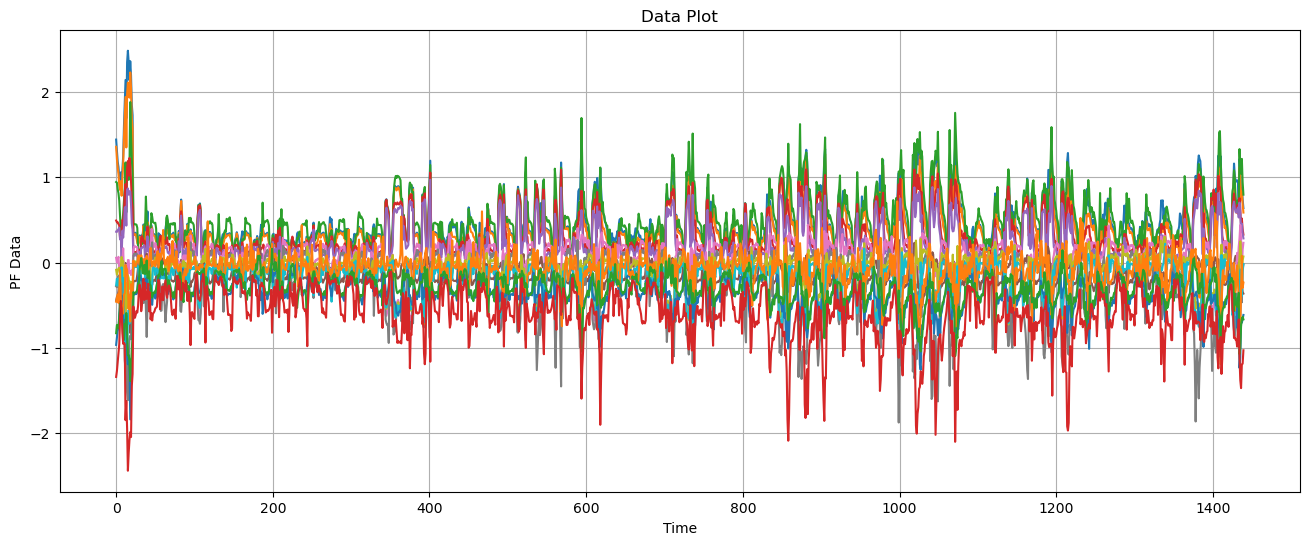

In [1]:
%load_ext autoreload
%autoreload 2
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx
import lib.plotGraph as plotGraph
import lib.ioFile as ioFile
import lib.powerfun as powerfun
import lib.graph as graph
import lib.threshold as threshold
import lib.residual as resd
import lib.subBase as subBase
import lib.utils as utils
import lib.ac_se_fdia as ac_se_fdia
from skimage.filters import threshold_li
import pandas as pd
import lib.cycle_space as csp
import tqdm
from scipy.stats import chi2
from lib.read_ac_pf_csv import read_ac_power_flow_data
from scipy.linalg import qr
import pandapower as pp
import pandapower.networks as nw

mode= "AC" # DC
powerID=  14
IEEENames= ["IEEE 14", "IEEE 30", "IEEE 57", "IEEE 118"]
case_map = {14: nw.case14, 30: nw.case30, 57: nw.case57, 118: nw.case118}
net = case_map[powerID]()
outPutFile= False
datasource= "open" #open, matpower
# Load MATLAB file
opensource_file= f"C:/Users/30678/Desktop/large_files/1_1_ac_power_flow_data/pglib_opf_case{powerID}_ieee.csv"
matpower_file= f'matpower/test_data/{mode}_case{powerID}_.mat' #14, 118, 57, 30
Chenhan_file= f"data/ac/results{powerID}_AC.xlsx"
DC_file= f'data/paper_2/results{powerID}.xlsx' # DC
#
pfData, phaseData, H, A, qfData, resistance, voltage, reactance= ioFile.read_mat_power(matpower_file, normalize= False)

if datasource=="open":
    voltage, phaseData, pfData, pfDataT, qfData, qfDataT = \
        read_ac_power_flow_data(opensource_file, maxLen= 1000)
# pfData = np.vstack([np.zeros((1, pfData.shape[1])), pfData[1:, :]-pfData[:-1, :]])
pfData, _=ioFile.read_excel_power(DC_file, id1= 0, id2= 0)
#
noZeroBranches= np.nonzero(np.abs(H).sum(axis= 0)!=0)
H= H[:, noZeroBranches].squeeze()
# A= A[:, noZeroBranches].squeeze()
param= np.sum(np.abs(H), axis= 1, keepdims= True)/2
m= H.shape[0]
n= H.shape[1]
rankH= n-1
stdOfNoise= 1e-2
numTrain= m*2
numTest= 1000
#
phaseData= (np.linalg.pinv(H)@pfData.T).T
normalPfData= H.dot(phaseData.T).T
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
noiseE= noiseVector*stdOfNoise
noisePfData= pfData.copy()+noiseE
trainDataNp= noisePfData[:numTrain, :]
testDataNp= noisePfData[numTrain:, :]
plotTimeSeries= True 
if plotTimeSeries:
    plt.figure(figsize=(16, 6))
    for i in range(phaseData.shape[1]):
        plt.plot(phaseData[:, i], label=i)
    plt.title('Data Plot')
    plt.xlabel('Time')
    plt.ylabel('PF Data')
    plt.grid(True)
    plt.show()

Running Subspace Estimation: K=40 samples, m=20 sensors, n=14 states.
(20, 13)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Successfully computed detection space basis (shape (20, 7)).
1.0982604671433382
(20, 7)
(40, 20)


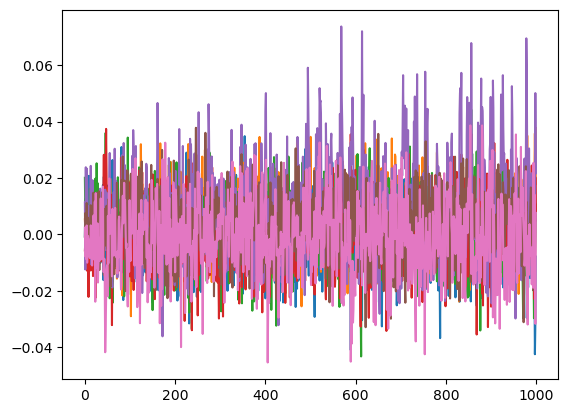

In [26]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from scipy.linalg import null_space
import warnings



def complexFun(eigvals, m, T):
    eigvalsDec= eigvals.copy()
    c= T/m
    for i in range(eigvalsDec.shape[0]):
        eigvalsDec[i]= T/((1-c*T/m*np.sum(1/(1-eigvals))**2))
        # print(np.sum(1/(eigvals[i]-eigvals)))
    print(eigvalsDec)
    return eigvalsDec

def compute_detection_subspace(Z, n, sigma, rcond_tol=1e-10): 
    K, m = Z.shape
    print(f"Running Subspace Estimation: K={K} samples, m={m} sensors, n={n} states.")
    # --- Step 1 & 2: Normalize Z ---
    # Standardize data (mean 0, variance 1)
    Znorm= Z-np.mean(Z, axis= 0)[None, :]
    C= Znorm.T@Znorm
    # --- Step 3: Calculate Covariance Matrix C_hat ---
    C_hat = C#/(sigma**2)
    # --- Step 4 & 5: Modify Eigenvalues & Reconstruct M_c_hat ---
    eigvals, eigvecs = np.linalg.eigh(C_hat)
    
    # Modify eigenvalues: lambda_tilde = max(0, lambda_i - sigma^2_est)
    modified_eigvals = np.maximum(0, eigvals - sigma**2)
    
    # Reconstruct M_c_hat = V * diag(modified_eigvals) * V.T
    M_c_hat = eigvecs @ np.diag(modified_eigvals) @ eigvecs.T
    
    # --- Step 6: Estimate Subspace W_hat ---
    # Perform eigen-decomposition on the "cleaned" matrix M_c_hat
    new_eigvals, new_eigvecs = np.linalg.eigh(M_c_hat)
        
    # Get indices of n largest eigenvalues (in descending order)
    top_n_indices = np.argsort(new_eigvals)[::-1][:n-1]
    
    # W_hat (m, n) is formed by the n principal eigenvectors
    W_hat = new_eigvecs[:, top_n_indices]
    
    # --- Step 7: Compute Left Null Space (Detection Space) ---
    # The left null space of W_hat (null(W_hat.T)) is the
    # orthogonal complement of the estimated column space.
    
    print(W_hat.shape)
    
    # detection_space_basis = null_space(W_hat, rcond=rcond_tol)
    U, S, V= np.linalg.svd(W_hat.T)
    print(S)
    detection_space_basis= V[-(m-n+1):, :].T

    print(f"Successfully computed detection space basis (shape {detection_space_basis.shape}).")
    return detection_space_basis

cSpaceNoise6= compute_detection_subspace(noisePfData[:numTrain, :], n, stdOfNoise)
error6= noisePfData[:numTest, :]@cSpaceNoise6
plt.plot(error6)
print(np.linalg.norm(error6))
print(cSpaceNoise6.shape)
print(noisePfData[:numTrain, :].shape)


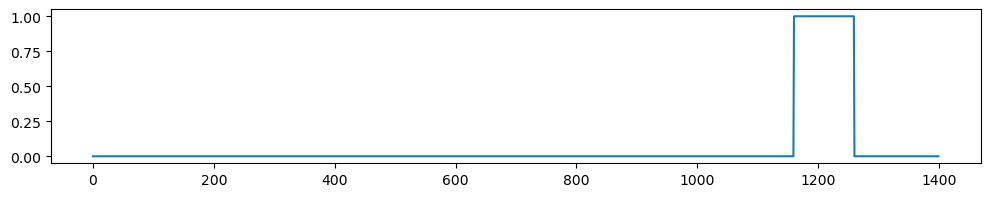

In [27]:

attackPeriod= np.linalg.norm((normalPfData-pfData)[numTrain:, ], axis= 1)>1e-8
plt.figure(figsize=(12, 2)) 
plt.plot(attackPeriod) 
tmpPdData= pfData+noiseVector*1e-3
wholeRight= tmpPdData[:m+1, :].T@(tmpPdData[:m+1, :])
spaningTreeList, leftLinksSet= csp.get_spanning_tree(pfData[:m+1, :], rankH=rankH, m=m)
cycleList, treeLinks= csp.get_cycle_and_tree(spaningTreeList, leftLinksSet, wholeRight, m)
_, cSpaceClean, _= resd.cycle_residual(pfData[:numTrain, :], rankH, m, pfData[numTrain:, :], cycleList)
NcSpaceClean= cSpaceClean@np.linalg.pinv(cSpaceClean.T@cSpaceClean)@cSpaceClean.T

In [28]:
Znorm= noisePfData[:numTrain, :]#-np.mean(noisePfData[:numTrain, :], axis= 0)[None, :]
U, S, V= np.linalg.svd(Znorm.T@Znorm)
nullSpace= V[-(1):, :].T# m-n+1
print(S[-4:])
error0= noisePfData[:numTest, :]@nullSpace
print(np.linalg.norm(error0))
_, cSpaceNoise1, _= resd.cycle_residual(noisePfData[:numTrain, :], rankH, m, noisePfData[:numTrain, :], cycleList)
error1= noisePfData[:numTest, :]@cSpaceNoise1
cycleList2= cycleList.copy()
for k in range(100):
    countT= 0
    for i in range(len(cycleList2)):
        for j in range(i+1, len(cycleList2)):
            c1= cycleList2[i]
            c2= cycleList2[j]
            intersect= c1&c2
            if len(intersect):
                left1= c1-intersect
                left2= c2-intersect
                newCyc= list(left1|left2)
                if len(newCyc)-np.linalg.matrix_rank(H[newCyc, :])==1:
                    if len(left1)>len(intersect):
                        cycleList2[j]= left1|left2
                        countT+=(len(intersect)-len(left1))
                    elif len(left2)>len(intersect):
                        cycleList2[i]= left1|left2
                        countT+=(len(intersect)-len(left2))
    if countT==0:
        break
print(cycleList)
# for cycle in cycleList:
#     print(len(cycle)-np.linalg.matrix_rank(H[list(cycle), :]), end=" ")
#     pass
G, node_pair2id = graph.from_A_to_G(A, param)
minimum_cycle_b= nx.minimum_cycle_basis(G, weight="weight")
print(minimum_cycle_b)
minimum_cycle_b= [list(i) for i in minimum_cycle_b]
minimum_cycle_e= []
for nodeCycle in minimum_cycle_b:
    S = G.subgraph(list(nodeCycle))
    linkCycle= [node_pair2id[(nodeCycle[i-1], nodeCycle[i])] for i in range(len(nodeCycle))]
    minimum_cycle_e.append(set(linkCycle))
    pass
print(minimum_cycle_e)
for cycle in cycleList:
    if len(cycle)==2:
        minimum_cycle_e.append(cycle)
_, cSpaceNoise5, _= resd.cycle_residual(noisePfData[:numTrain, :], rankH, m, noisePfData[numTrain:, :], minimum_cycle_e)
error5= (noisePfData[:numTest, :]@cSpaceNoise5)
_, cSpaceNoise4, _= resd.cycle_residual(pfData[:1000, :], rankH, m, pfData[1000:, :], minimum_cycle_e)
error4= noisePfData[:numTest, :]@cSpaceNoise4
for cycle in minimum_cycle_e:
    if len(cycle)-np.linalg.matrix_rank(H[list(cycle), :])!= 1:
        print(cycle)
    pass

[0.00173045 0.00140781 0.00081834 0.00069788]
0.3445235491331596
[{0, 1, 4}, {2, 4, 5, 6}, {3, 4, 6}, {8, 14, 7}, {6, 7, 9, 10, 14, 15, 17}, {18, 11, 12}, {10, 12, 15, 16, 17, 19}]
[[11, 12, 5], [2, 3, 1], [4, 1, 0], [3, 8, 13, 12, 5, 4, 1], [3, 8, 6], [3, 4, 1], [12, 13, 8, 9, 10, 5]]
[{18, 11, 12}, {2, 3, 5}, {0, 1, 4}, {3, 4, 8, 9, 12, 16, 19}, {8, 14, 7}, {3, 4, 6}, {10, 12, 15, 16, 17, 19}]


In [29]:
from scipy.stats import chi2
alpha = 0.001
critical_value = chi2.ppf(1 - alpha, df=m-n+1)
print("Critical value (df=1):", critical_value)

subH= H
numTrain= 10*m+1
numPop= 1e4
subE= np.random.randn(numTrain, subH.shape[0])*stdOfNoise
Xi= np.random.randn(subH.shape[1], numTrain)
subZ= (subH@Xi).T
subZE= subZ+ subE
U, S, V= np.linalg.svd(subZE)
Xipop= np.random.randn(subH.shape[1], int(numPop))
popE= np.random.randn(int(numPop), subH.shape[0])*stdOfNoise
popZ= (subH@Xipop).T+popE
# Ni= cSpaceClean[cycleI, cidx]
NiNoise= V[-1, :]
_, cSpaceNoise5, _= resd.cycle_residual(subZE, rankH, m, subZE, minimum_cycle_e)
_, cSpace5, _= resd.cycle_residual(subZ, rankH, m, subZ, minimum_cycle_e)
print(np.sum(np.mean(np.square(popZ@(cSpaceNoise5)), axis= 0)))
theorioticalRiskT= []
for cyc in minimum_cycle_e:
    theorioticalRiskT.append(stdOfNoise**2*(len(cyc)-1)/(numTrain-len(cyc)))
theorioticalVar= (0*np.array(theorioticalRiskT)+stdOfNoise**2)[None, :]
residual= np.sum(np.square(popZ@(cSpace5))/theorioticalVar, axis= 1)
print(np.sum(residual>critical_value)/numPop)

Critical value (df=1): 24.321886347856854
0.0007058337469000792
0.0036


100%|██████████| 100/100 [00:05<00:00, 18.02it/s]


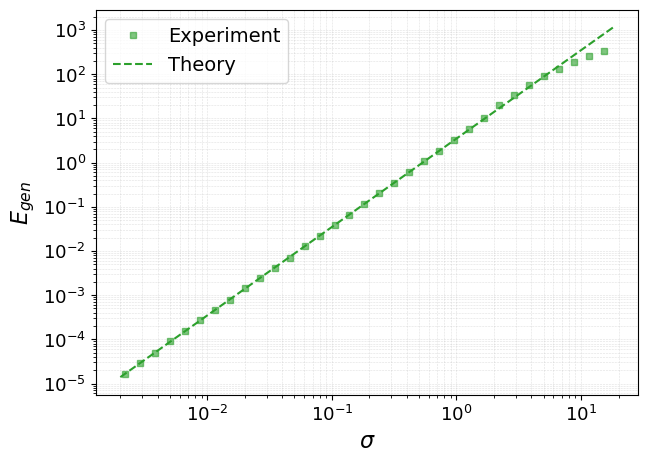

In [34]:
experimentRiskCyc= []
theorioticalRiskCyc= []
empiricalRiskCyc= []
loops= 100
numPop= 2e3
Xipop= np.random.randn(H.shape[1], int(numPop))
popE= np.random.randn(int(numPop), H.shape[0])

for j in tqdm.tqdm(range(loops)):
    break
    dataCollect= []
    dataCollect2= []
    dataCollect3= []
    cidx= 1
    numTrain= m+1
    stdOfNoise= 1e-1*10**(-4+j/loops*4)#-4 to 0
    popZ= (H@Xipop).T+popE*stdOfNoise
    for i in range(100):
        # 
        subH= H
        subE= np.random.randn(numTrain, subH.shape[0])*stdOfNoise
        Xi= np.random.randn(subH.shape[1], numTrain)
        subZ= (subH@Xi).T
        subZE= subZ+ subE
        U, S, V= np.linalg.svd(subZE)
        # Ni= cSpaceClean[cycleI, cidx]
        NiNoise= V[-1, :]
        _, cSpaceNoise5, _= resd.cycle_residual(subZE, rankH, m, subZE, minimum_cycle_e)
        # hatNi= cSpaceNoise1[cycleI, cidx]
        # Deltai= (-(np.linalg.pinv(subZ))@subE@Ni)[:, None]
        # dataCollect.append(np.linalg.norm(subH.T@Deltai)**2)
        dataCollect2.append((np.mean(np.square(popZ@(cSpaceNoise5)), axis= 0)))
        dataCollect3.append((np.mean(np.square(subZE@(cSpaceNoise5)), axis= 0)))
    theorioticalRiskT= 0
    for cyc in minimum_cycle_e:
        theorioticalRiskT+=(stdOfNoise**2*(len(cyc)-1)/(numTrain-len(cyc)))
    theorioticalRiskCyc.append(theorioticalRiskT)#= rank of subH
    # print(Deltai.T@Deltai*stdOfNoise**2)
    # print(np.mean(dataCollect))
    experimentRiskCyc.append(np.sum(np.mean(dataCollect2, axis= 0)-stdOfNoise**2))
    empiricalRiskCyc.append(np.abs(np.sum(np.mean(dataCollect3, axis= 0)-stdOfNoise**2)))
experimentRisk= []
experimentRisk2= []
theorioticalRisk= []
empiricalRisk= []
numSpales= []
for j in tqdm.tqdm(range(loops)):
    dataCollect= []
    dataCollect2= []
    dataCollect3= []
    dataCollect4= []
    cidx= 0
    numTrain= m*2#+1, -5, +7
    numPop= 1e3
    stdOfNoise= 2*10**(-3+j/loops*4)
    popZ= (H@Xipop).T+popE*stdOfNoise
    numSpales.append(stdOfNoise)
    for i in range(100):
        # 
        HE= np.random.randn(numTrain, H.shape[0])*stdOfNoise
        HX= np.random.randn(H.shape[1], numTrain)
        HZ= (H@HX).T
        # U, S, V= np.linalg.svd(HZ.T@HZ)
        # Ni= V[-(m-n+1):, :].T
        HZE= HZ+HE
        U, S, V= np.linalg.svd(HZE.T@HZE)
        NiE= V[-(m-n+1):, :].T
        # Xipop= np.random.randn(H.shape[1], int(numPop))
        # popE= np.random.randn(int(numPop), H.shape[0])*stdOfNoise
        # popZ= (H@Xipop).T+popE 
        # Deltai= (-np.linalg.pinv(HZ)@HE@Ni)
        # dataCollect.append(np.linalg.norm(H.T@Deltai)**2)
        dataCollect2.append(np.mean(np.square(popZ@(NiE))))
        dataCollect3.append(np.mean(np.square(HZE@(NiE))))
        dataCollect4.append(np.mean(np.square(popZ@(NiE)), axis= 0))
    theorioticalRisk.append((m-n+1)*stdOfNoise**2*(n-1)/(numTrain-n))#= rank of subH
    # print(Deltai.T@Deltai*stdOfNoise**2)
    # print(np.mean(dataCollect)/(m-n+1))
    experimentRisk2.append(np.mean(dataCollect4, axis= 0)-stdOfNoise**2)
    experimentRisk.append((m-n+1)*(np.mean(dataCollect2)-stdOfNoise**2))
    empiricalRisk.append(np.abs((m-n+1)*(np.mean(dataCollect3)-stdOfNoise**2)))
plt.figure(figsize=(7,5))
# plt.plot(numSpales[::3], empiricalRiskCyc[::3], '^', markersize=4, alpha=0.2, color='C0', label= "MCB (Emp exp.)")
# plt.plot(numSpales[1::3], experimentRiskCyc[1::3], 'o', markersize=4, alpha=0.6, color='C0', label= "MCB (Pop exp.)")
# plt.plot(numSpales, theorioticalRiskCyc,linewidth=1.5, label= "MCB (Pop theory)", color='C0', linestyle='--')
# plt.plot(numSpales[::3], empiricalRisk[::3], 'D', markersize=4, alpha=0.2, color='C2', label= "SVD (Emp exp.)")
plt.plot(numSpales[1::3], experimentRisk[1::3], 's', markersize=4, alpha=0.6, color='C2', label= "Experiment")
plt.plot(numSpales, theorioticalRisk, linewidth=1.5, label= "Theory", color='C2', linestyle='--')
plt.xlabel(r'$\sigma$', fontsize=16)
plt.ylabel(r'$E_{gen}$', fontsize=16)
plt.grid(which='both', linestyle='--', linewidth=0.4, alpha=0.4)
plt.yscale("log")
plt.xscale("log")
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=14)
# plt.title('Risk vs. Sample Size: MCB vs. SVD Null-Space Estimators')


In [7]:
n= 19
H= np.random.randn(20, n)
H= H/np.linalg.norm(H)
U, S, V= np.linalg.svd(H@H.T)
m= H.shape[0]
rankH= np.linalg.matrix_rank(H)
nullity= m-rankH
Ni= V[-nullity:, :]
dirMat= np.random.randn(H.shape[1], 1)
numPop= 1e3
loops= 10

expEmp= []
expGen= []
expEmpStd= []
expGenStd= []
expEmpCal= []
expGenCal= []
numSpales= []
tmpWants = []
tmpWants2 = []
for j in tqdm.tqdm(range(loops)):
    stdOfNoise= 1e-2
    empList= []
    genList= []
    numTrain= rankH*2+int(j*10/loops)
    numSpales.append(numTrain)
    tmpWanted= []
    tmpWanted2= []
    for i in range(1000):
        Xipop= np.random.randn(H.shape[1], int(numPop))*dirMat
        popE= np.random.randn(int(numPop), H.shape[0])
        popZ= (H@Xipop).T
        popET= popE*stdOfNoise
        popZE= popZ+popET
        HE= (np.random.randn(numTrain, H.shape[0])*stdOfNoise).T
        HX= np.random.randn(H.shape[1], numTrain)*dirMat
        HZ= H@HX
        HZE= HZ+HE
        U, S, V= np.linalg.svd(HZE@HZE.T)
        # NiE= (np.mean(V[-1:, :], axis=0)/np.linalg.norm(np.mean(V[-1 :, :], axis=0)))[:, None]
        NiE= V[-nullity:, :]
        if NiE[0, 0]*Ni[0, 0]<0:
            NiE=-NiE
        epsilon= (NiE-Ni).T
        calEpsilon= np.linalg.pinv(HZ.T+HE.T)@HE.T@Ni.T
        tmpWanted.append(np.mean(stdOfNoise**2*epsilon.T@epsilon))
        tmpWanted2.append(np.mean(epsilon.T@HE@HE.T@epsilon))
        empList.append(np.mean(np.square(HZE.T@NiE.T)))
        genList.append(np.mean(np.square(popZE@NiE.T)))
    expEmp.append(np.mean(empList))
    expGen.append(np.mean(genList))
    expEmpStd.append(np.std(empList))
    expGenStd.append(np.std(genList))
    expEmpCal.append(stdOfNoise**2-rankH/numTrain*stdOfNoise**2)
    expGenCal.append(stdOfNoise**2+rankH/(numTrain-n)*stdOfNoise**2)
    tmpWants.append(np.mean(tmpWanted))
    tmpWants2.append(np.mean(tmpWanted2)/numTrain)
print("SNR:", np.linalg.norm(HZ)/np.linalg.norm(HE))

100%|██████████| 10/10 [00:11<00:00,  1.18s/it]


SNR: 27.914847766675166


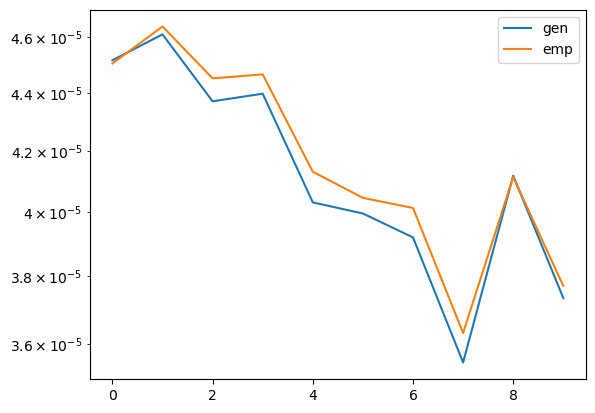

In [8]:
plt.plot(tmpWants, label= "gen")
plt.plot(tmpWants2, label= "emp")
plt.legend()
plt.yscale("log")

In [9]:
epsilon= (NiE-Ni).T
calEpsilon= -np.linalg.pinv(HZ.T)@HE.T@Ni.T
A= HZ.T+HE.T
M= np.linalg.inv((HZ+HE)@(HZ.T+HE.T))
print(calEpsilon.T)
print(-epsilon.T)
print(np.linalg.norm(calEpsilon.T+Ni))

[[-0.02917222 -0.07637191 -0.1945866  -0.08682236  0.03315246 -0.06162009
   0.09927698 -0.03656774  0.11748206 -0.09783728  0.03173475  0.09547425
   0.04164609 -0.08860716  0.02369682  0.111382    0.03286132  0.01766463
   0.09551059 -0.06269986]]
[[ 0.04898482  0.03809182  0.12221737  0.05780749 -0.00647969  0.04008407
  -0.05946718  0.0187777  -0.05298025  0.090057   -0.04989356 -0.08788507
  -0.00411092  0.07238921 -0.00762438 -0.09202299  0.00496826 -0.00812985
  -0.05409083  0.02312298]]
1.067084886508138


In [10]:
deltaVector= 0
stdOfNoise= 1e-3
numTrain= m*2
n= 19
H= np.random.randn(20, n)
HE= (np.random.randn(numTrain, H.shape[0])*stdOfNoise).T
HX= np.random.randn(H.shape[1], numTrain)
HZ= H@HX
HZE= HZ+HE
U, S, V= np.linalg.svd(HZ.T)
Ni= V[-nullity:, :]
U, S, V= np.linalg.svd(HZE.T)
NiE= V[-nullity:, :]
epsilon= (NiE-Ni).T
K= -np.linalg.pinv(HZ.T)@HE.T
print(np.linalg.norm(K))
print(np.linalg.norm(K@K))
print(np.max(np.real(np.linalg.eigvals(K))))
print("SNR:", np.linalg.norm(HZ)/np.linalg.norm(HE))
U, S, V= np.linalg.svd(HZE)
Sigma = np.zeros((m, numTrain))
Sigma[rankH:m, rankH:m]= np.diag(S[rankH:m])
cleanedHZE1= U@Sigma@V
lambdaNull= np.sqrt(numTrain*stdOfNoise**2*(1+rankH/(numTrain-n)))
Sigma[rankH:m, rankH:m] = lambdaNull
cleanedHZE2= U@Sigma@V
# print(np.linalg.norm(HZE-cleanedHZE1-HZ))
# print(np.linalg.norm(HZE-cleanedHZE2-HZ))
# print(Sigma[rankH:m, rankH:m])
# print((stdOfNoise**2*(1-rankH/(numTrain))))
K= -np.linalg.pinv(HZ@HZ.T)@HZ@HE.T
L= np.linalg.pinv(HZ@HZ.T)@HE@HZ.T
M= np.linalg.pinv(HZ@HZ.T)@HE@HE.T
G= np.linalg.pinv(HZ@HZ.T)


0.005622443148656852
4.982598184427672e-06
0.0008151794196971957
SNR: 4280.915013489345


In [11]:
calEpsilon= K@Ni.T
tmp= np.eye(K.shape[0])
# print(K.shape)
for i in range(10):
    tmp= tmp@(-(K.T+L+M))
    pass
# print(np.linalg.norm(tmp))
NiE2= (calEpsilon.T+Ni)/np.linalg.norm(calEpsilon.T+Ni)
para= (Ni@np.linalg.pinv(K+np.eye(K.shape[0])).T@np.linalg.pinv(K+np.eye(K.shape[0]))@Ni.T)[0, 0]
D3= (np.linalg.pinv(K+np.eye(K.shape[0]))@K@Ni.T).T
NiE3= (D3+Ni)/np.linalg.norm(D3+Ni)
Pz= HZ.T@np.linalg.pinv(HZ@HZ.T)@HZ
term1= np.linalg.pinv(HZ@HZ.T)@HE@(np.eye(HE.shape[1])-Pz)@HE.T@Ni.T
NiE4= (K@Ni.T+K@K@Ni.T+K@K@K@Ni.T-term1-np.square(np.linalg.norm(K@Ni.T))*Ni.T/2).T+Ni
NiE4= NiE4/np.linalg.norm(NiE4)
term1= np.linalg.pinv(HZ@HZ.T)@(HZ@HZ.T)+np.linalg.pinv(HZ@HZ.T)@(HZE@HZE.T-HZ@HZ.T)
print(term1.shape)
NiE5= -(np.linalg.inv(np.eye(K.shape[0])-K+L+M)@(K+M)@Ni.T).T+Ni

print(np.linalg.norm(NiE-NiE5))

NiE5= NiE5/np.linalg.norm(NiE5)
if NiE[0, 0]*NiE2[0, 0]<0:
    NiE2= -NiE2
if NiE[0, 0]*NiE3[0, 0]<0:
    NiE3= -NiE3
if NiE[0, 0]*NiE4[0, 0]<0:
    NiE4= -NiE4
if NiE[0, 0]*NiE5[0, 0]<0:
    NiE5= -NiE5
print(np.linalg.norm(NiE2-NiE))
print(np.linalg.norm(NiE3-NiE))
print(np.linalg.norm(NiE-NiE4))
print(np.linalg.norm(NiE-NiE5))
print()
print(np.linalg.norm(HZE.T@NiE2.T))
print(np.linalg.norm(HZE.T@NiE3.T))
print(np.linalg.norm(HZE.T@NiE4.T))
print(np.linalg.norm(HZE.T@NiE5.T))
print(np.linalg.norm(HZE.T@NiE.T))
# 3， 5， 9，11

(20, 20)
1.9999974401379512
3.031186619416167e-06
4.427433765297616e-06
2.6297109534971446e-09
0.004524854822486334

0.004215390848379303
0.004215438345516984
0.004215374832204411
0.012544097436544657
0.004215374832168325


In [12]:
lambdA= np.square(np.linalg.norm(HZE.T@NiE.T))

Beta= np.eye(K.shape[0])-K+L+M-lambdA*G
BetaN1= np.linalg.inv(Beta)
w= (BetaN1@Ni.T).T
v= (BetaN1@(-K+M)@Ni.T).T
a= 1/2*np.square(np.linalg.norm(w))
b= (Ni@w.T-w@v.T)[0, 0]
c= (1/2*np.square(np.linalg.norm(v))-Ni@v.T)[0, 0]

alpha= (-b+np.sqrt(b**2-4*a*c))/(2*a) 
e0= -v+(alpha)*w
Ni6= e0+Ni
if NiE[0, 0]*Ni6[0, 0]<0:
    Ni6= -Ni6
print(np.linalg.norm(Ni6))
print(NiE-Ni6)


0.9999999999999997
[[-1.38777878e-16  1.52655666e-16 -1.34614542e-15 -3.88578059e-16
   0.00000000e+00 -1.08246745e-15  1.11022302e-16  5.34294831e-16
  -8.32667268e-17 -9.71445147e-17 -4.99600361e-16 -3.60822483e-16
   2.49800181e-16 -1.66533454e-16  1.87350135e-16 -1.38777878e-17
   3.33066907e-16 -4.16333634e-16 -1.94289029e-16  1.66533454e-16]]


In [13]:
print(HZ.shape)
print(HE.shape)
print(HZE.shape)
print(H.shape)
print(Ni.shape)

(20, 40)
(20, 40)
(20, 40)
(20, 19)
(1, 20)


In [14]:
calEpsilon= np.linalg.inv(np.linalg.inv(HE@HE.T)@HE@HZ.T+np.eye(HZ.shape[0]))@Ni.T
NiE2= (calEpsilon.T+Ni)/np.linalg.norm(calEpsilon.T+Ni)
deltaVector+= NiE2-NiE
print(np.linalg.norm(NiE2))
print()
print(np.linalg.norm(HZE.T@(NiE2-Ni).T))
print(np.linalg.norm(HZE.T@(NiE-Ni).T))
print()
print(np.linalg.norm(HZ.T@(NiE2-Ni).T))
print(np.linalg.norm(HZ.T@(NiE-Ni).T))
print()
print(np.linalg.norm(HZE.T@(NiE2).T))
print(np.linalg.norm(HZE.T@(NiE).T))

1.0

2.4966650887861308e-14
0.010294630033920484

2.496647913525066e-14
0.005908134865944904

0.007257502572001521
0.004215374832168325


In [15]:
print(np.linalg.norm((HZ.T+HE.T)@epsilon-HE.T@Ni.T))
print(np.linalg.norm((HZ.T+HE.T)@calEpsilon-HE.T@Ni.T))
print(np.linalg.norm((HZ.T+HE.T)@(calEpsilon-Ni.T)))
print((calEpsilon-Ni.T).shape)
print(np.linalg.norm(HE.T@calEpsilon))
print(np.trace(np.linalg.pinv(H@H.T))*stdOfNoise**2)
print(np.square(np.linalg.norm(np.linalg.pinv(H)))*stdOfNoise**2)


0.017306996194027566
4.7685700699552385e-14
4.9653736416874124e-14
(20, 1)
0.0072575025719962515
2.3420765972496327e-05
2.3420765972496618e-05


In [16]:
H= np.random.randn(4, 4)
U, S, V= np.linalg.svd(H@H.T)
S[-1]=0
H= U@np.diag(S)@V
Herror= np.random.randn(H.shape[0], H.shape[1])
noiseH= H+Herror
print(np.linalg.matrix_rank(H))
print(np.linalg.matrix_rank(np.linalg.inv(H+Herror)))
print(np.linalg.matrix_rank(np.linalg.pinv(H)))
# print(H@np.linalg.pinv(H)+U[:, -1:]@U[:, -1:].T)
# print(noiseH@np.linalg.pinv(noiseH))
print((U[:, -1:]@U[:, -1:].T))

3
4
3
[[ 0.56089399 -0.43191325 -0.14025714  0.20017694]
 [-0.43191325  0.33259235  0.10800422 -0.15414512]
 [-0.14025714  0.10800422  0.0350727  -0.05005624]
 [ 0.20017694 -0.15414512 -0.05005624  0.07144096]]


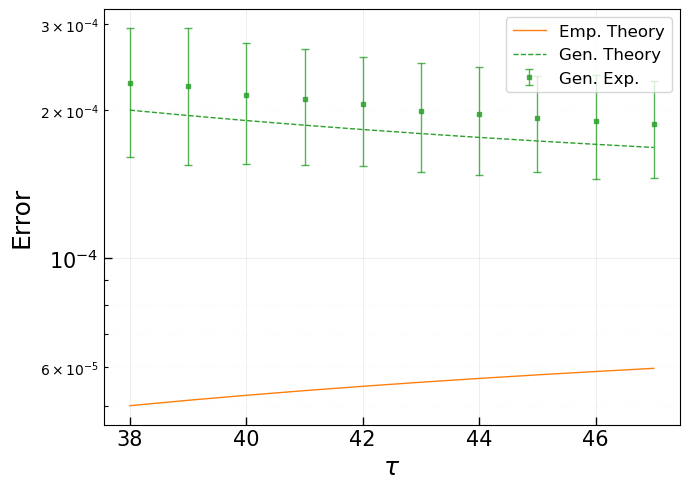

In [17]:
# Convert lists to numpy arrays for easy math operations (like jittering)
numSpales_arr = np.array(numSpales)
jitter = 0  # Adjust this value based on your X-axis scale
plt.figure(figsize=(7, 5))
# 1. Empirical Data: Jittered slightly to the left
# plt.errorbar(numSpales_arr - jitter, expEmp, yerr=expEmpStd, 
#              fmt='D', markersize=3, capsize=3, elinewidth=1,
#              color='C1', label='Emp. Exp.', alpha=0.8)
# 2. Empirical Theory: Solid line
plt.plot(numSpales_arr - jitter, np.array(expEmpCal), linewidth=1, 
         label="Emp. Theory", color='C1', linestyle='-')
# 3. General Data: Jittered slightly to the right
plt.errorbar(numSpales_arr + jitter, expGen, yerr=expGenStd, 
             fmt='s', markersize=3, capsize=3, elinewidth=1,
             color='C2', label='Gen. Exp.', alpha=0.8)
# 4. General Theory: Dashed line for visual distinction (Colorblind friendly)
plt.plot(numSpales_arr , np.array(expGenCal), linewidth=1, 
         label="Gen. Theory", color='C2', linestyle='--')
# Aesthetics
plt.xlabel(r'$\tau$', fontsize=18)
plt.ylabel(r'Error', fontsize=18)
plt.yscale("log")
# Improved Grid: Distinct major and minor lines
plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.3)
plt.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.2)
plt.xticks(fontsize=15)
plt.yticks(fontsize=15)
plt.tick_params(axis='both', which='major', direction='in', length=6, width=1)
plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
# Legend: Organized into two columns to save vertical space if needed
plt.legend(fontsize=12, loc='upper right', frameon=True, ncol=1)
plt.tight_layout()
plt.show()

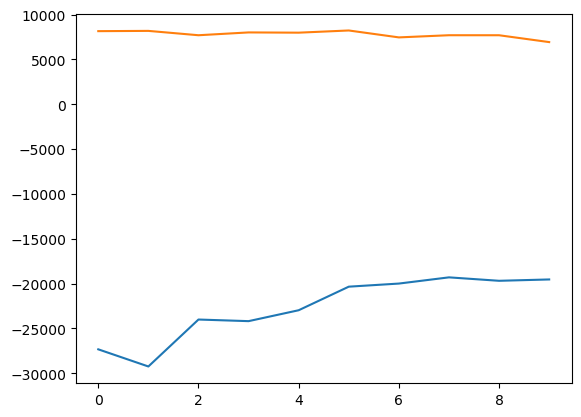

In [18]:
deltaErrorGen= np.array(expGen)-np.array(expGenCal)
deltaErrorEmp= np.array(expEmp)-np.array(expEmpCal)
plt.plot(-deltaErrorGen/stdOfNoise**3)
plt.plot(-deltaErrorEmp/stdOfNoise**3)
# plt.yscale("log")

In [56]:
n= 10
H= np.random.randn(20, n)
H= H/np.linalg.norm(H)
U, S, V= np.linalg.svd(H@H.T)
m= H.shape[0]
rankH= np.linalg.matrix_rank(H)
nullity= m-rankH
Ni= V[-nullity:, :]
dirMat= np.random.randn(H.shape[1], 1)
numPop= 1e3
loops= 20

expEmp= []
expGen= []
expEmpStd= []
expGenStd= []
expEmpCal= []
expEmpCalLa= []
expGenCal= []
expGenCalLa= []
numSpales= []
tmpWants = []
tmpWants2 = []
tmpWants3 = []
tmpWantsCal= []
expEmpCal3= []
for j in tqdm.tqdm(range(loops)):
    stdOfNoise= 100*10**(-6+j/loops*6)
    # stdOfNoise= 10
    empList= []
    genList= []
    HXMean= 0
    numTrain= n+5
    numSpales.append(stdOfNoise)
    tmpWanted= []
    tmpWanted2= []
    tmpWanted3= []
    for i in range(1000):
        Xipop= np.random.randn(H.shape[1], int(numPop))*dirMat
        popE= np.random.randn(int(numPop), H.shape[0])
        popZ= (H@Xipop).T
        popET= popE*stdOfNoise
        popZE= popZ+popET
        HE= (np.random.randn(numTrain, H.shape[0])*stdOfNoise).T
        HX= np.random.randn(H.shape[1], numTrain)*dirMat
        HZ= H@HX
        HZE= HZ+HE
        HXMean+= HX@HX.T
        U, S, V= np.linalg.svd(HZE@HZE.T)
        NiE= (np.mean(V[-nullity:, :], axis=0)/np.linalg.norm(np.mean(V[-nullity:, :], axis=0)))[:, None]
        NiE= V[-nullity:, :]
        # if NiE[0, 0]*Ni[0, 0]<0:
        #     NiE= -NiE
        empList.append(np.mean(np.square(HZE.T@NiE.T)))
        tmpWanted.append(np.mean(np.square(popZE@(NiE-Ni).T)))
        tmpWanted2.append(np.mean(np.square((popET@(Ni).T)).T@popET@(NiE-Ni).T))
        tmpWanted3.append(np.mean(np.square(popET@(Ni).T)))
        genList.append(np.mean(np.square(popZE@NiE.T)))
    expEmp.append(np.mean(empList))
    tmpWants.append(np.mean(tmpWanted))
    tmpWants2.append(np.mean(tmpWanted2))
    tmpWants3.append(np.mean(tmpWanted3))
    expGen.append(np.mean(genList))
    expEmpStd.append(np.std(empList))
    expGenStd.append(np.std(genList))

    expGenCal.append(stdOfNoise**2+rankH/(numTrain-n)*stdOfNoise**2)
    expGenCalLa.append(stdOfNoise**2+np.square(np.linalg.norm(H))/m)

    expEmpCal.append(stdOfNoise**2-rankH/numTrain*stdOfNoise**2)
    expEmpCal3.append((stdOfNoise**2*(numTrain-rankH)/(1+stdOfNoise**2*np.square(np.linalg.pinv(H)).sum()))/numTrain)

    U, S, V= np.linalg.svd(HE@HE.T)
    # print(S[-1]/stdOfNoise/stdOfNoise/numTrain)
    expEmpCalLa.append(stdOfNoise**2*(np.sqrt(numTrain)-np.sqrt(m))**2/numTrain+np.square(np.linalg.norm(H))/m)
print("SNR:", np.linalg.norm(HZ)/np.linalg.norm(HE))
print((np.sqrt(numTrain)-np.sqrt(m))**2/numTrain)

100%|██████████| 20/20 [00:22<00:00,  1.14s/it]


SNR: 0.004759562297961166
0.023932256574830283


In [57]:
U, S, V= np.linalg.svd(H@H.T)
m= H.shape[0]
rankH= np.linalg.matrix_rank(H)
nullity= m-rankH
Ni= V[-nullity:, :]
# print(Ni@np.linalg.pinv(H.T))

In [115]:
H= np.random.randn(20, 19)
stdOfNoise= 1e2
H= H/np.linalg.norm(H)

print(np.trace(np.linalg.pinv(H@H.T)))
print(np.square(np.linalg.norm(np.linalg.pinv(H))))

HE= (np.random.randn(numTrain, H.shape[0])*stdOfNoise).T
U, S, V= np.linalg.svd(H@H.T)
m= H.shape[0]
rankH= np.linalg.matrix_rank(H)
nullity= m-rankH
Ni= V[-nullity:, :]
HX= np.random.randn(H.shape[1], numTrain)*dirMat
HZ= H@HX
print((Ni@np.linalg.pinv(HZ.T)@HE.T@Ni.T)/(Ni@np.linalg.pinv(HZ@HZ.T)@Ni.T))
print(np.linalg.norm(np.linalg.pinv(HZ@HZ.T)@Ni.T))
print(np.linalg.norm(np.linalg.pinv(H@H.T)@Ni.T))


10362.31267277557
10362.312672775404


ValueError: operands could not be broadcast together with shapes (19,22) (10,1) 

In [40]:
U, S, V= np.linalg.svd(HE@HE.T)
print(S)
epsilon= NiE
epsilonCal= U[:, -nullity:].T
print(np.linalg.norm(HZE.T@epsilon.T))
print(np.linalg.norm(HZE.T@epsilonCal.T))


[7.90118992e+05 5.37247189e+05 5.11467496e+05 4.29310098e+05
 4.02044143e+05 3.40953060e+05 2.56025077e+05 2.08073033e+05
 1.85404778e+05 1.29182177e+05 1.13971868e+05 8.50583130e+04
 7.42172600e+04 6.43201539e+04 2.57229262e+04 2.30658844e+04
 1.83993347e+04 1.63947145e+04 3.64558417e+03 5.38328008e+02]
2.338256491882601
208.0915178824181


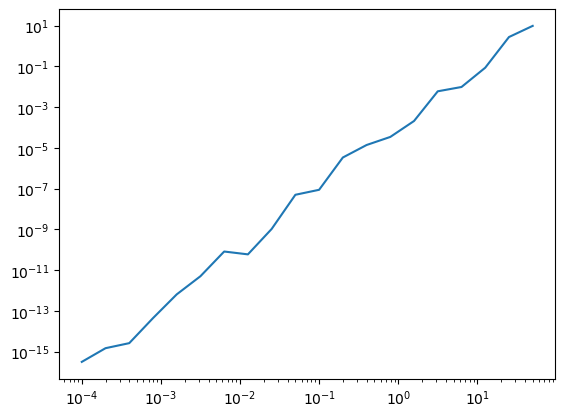

In [225]:
# plt.plot(numSpales, np.abs(np.array(tmpWants)))
plt.plot(numSpales, np.abs(np.array(tmpWants2)/numPop))
# plt.plot(numSpales, np.array(expGen))
# plt.plot(numSpales, expGenCalLa)
plt.yscale("log")
plt.xscale("log")

In [42]:
expEmpCalLa= []
for j in tqdm.tqdm(range(loops)):
    stdOfNoise= 100*10**(-7+j/loops*7)
    effectNullity= numTrain-rankH
    if effectNullity>nullity:
        effectNullity= nullity
    expEmpCalLa.append(stdOfNoise**2*((np.sqrt(numTrain)-np.sqrt(rankH))**2*effectNullity+(effectNullity+1)/2/numTrain**(1/3))/nullity/numTrain+np.square(np.linalg.norm(H))/m)
    # expEmpCalLa.append(stdOfNoise**2*((np.sqrt(numTrain)-np.sqrt(m))**2+(nullity+numTrain-m-1)*c/(numTrain**(2/3)))/numTrain+np.square(np.linalg.norm(H))/m)
    # expEmpCalLa.append(stdOfNoise**2*((np.sqrt(numTrain)-np.sqrt(m))**2+(nullity-1)*np.pi**(2/3)/((np.sqrt(numTrain)-np.sqrt(m))**(1/3)*m**(2/3)))/numTrain+np.square(np.linalg.norm(H))/m)

100%|██████████| 20/20 [00:00<?, ?it/s]


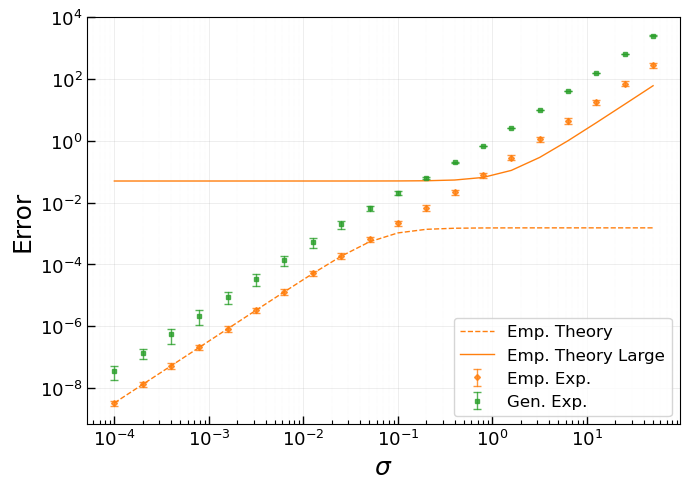

In [58]:
# Convert lists to numpy arrays for easy math operations (like jittering)
numSpales_arr = np.array(numSpales)
jitter = 0  # Adjust this value based on your X-axis scale
plt.figure(figsize=(7, 5))
# 1. Empirical Data: Jittered slightly to the left
plt.errorbar(numSpales_arr - jitter, expEmp, yerr=expEmpStd, 
             fmt='D', markersize=3, capsize=3, elinewidth=1,
             color='C1', label='Emp. Exp.', alpha=0.8)
# 2. Empirical Theory: Solid line
plt.plot(numSpales_arr - jitter, expEmpCal3, linewidth=1, 
         label="Emp. Theory", color='C1', linestyle='--')
plt.plot(numSpales_arr - jitter, expEmpCalLa, linewidth=1, 
         label="Emp. Theory Large", color='C1', linestyle='-')
# 3. General Data: Jittered slightly to the right
plt.errorbar(numSpales_arr + jitter, expGen, yerr=expGenStd, 
             fmt='s', markersize=3, capsize=3, elinewidth=1,
             color='C2', label='Gen. Exp.', alpha=0.8)
# 4. General Theory: Dashed line for visual distinction (Colorblind friendly)
# plt.plot(numSpales_arr + jitter, expGenCal, linewidth=1, 
#          label="Gen. Theory", color='C2', linestyle='--')
# plt.plot(numSpales_arr - jitter, expGenCalLa, linewidth=1, 
#          label="Gen. Theory Large", color='C2', linestyle='-')
# Aesthetics
plt.xlabel(r'$\sigma$', fontsize=18)
plt.ylabel(r'Error', fontsize=18)
plt.yscale("log")
plt.xscale("log")
# Improved Grid: Distinct major and minor lines
plt.grid(which='major', linestyle='-', linewidth=0.5, alpha=0.3)
plt.grid(which='minor', linestyle=':', linewidth=0.3, alpha=0.2)
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.tick_params(axis='both', which='major', direction='in', length=6, width=1)
plt.tick_params(axis='both', which='minor', direction='in', length=3, width=0.8)
# Legend: Organized into two columns to save vertical space if needed
plt.legend(fontsize=12, loc='lower right', frameon=True, ncol=1)
plt.tight_layout()
plt.show()

In [18]:
n= 15
H= np.random.randn(20, n)
H= H/np.linalg.norm(H)
U, S, V= np.linalg.svd(H@H.T)
m= H.shape[0]
rankH= np.linalg.matrix_rank(H)
nullity= m-rankH
Ni= V[-nullity:, :]
numPop= 1e3
loops= 30

expEmp= []
expGen= []
expEmpStd= []
expGenStd= []
expEmpCal= []
expGenCal= []
numSpales= []
tmpWants = []
tmpWants2 = []
tmpWantsCal= []
for j in tqdm.tqdm(range(loops)):
    stdOfNoise= 10*10**(-7+j/loops*7)
    empList= []
    genList= []
    HXMean= 0
    numTrain= m+5
    numSpales.append(stdOfNoise)
    tmpWanted= []
    tmpWanted2= []
    for i in range(1000):
        Xipop= np.random.randn(H.shape[1], int(numPop))
        popE= np.random.randn(int(numPop), H.shape[0])
        popZ= (H@Xipop).T
        popET= popE*stdOfNoise
        popZE= popZ+popET
        HE= (np.random.randn(numTrain, H.shape[0])*stdOfNoise).T
        HX= np.random.randn(H.shape[1], numTrain)
        HZ= H@HX
        HZE= HZ+HE
        HXMean+= HX@HX.T
        U, S, V= np.linalg.svd(HZE@HZE.T)
        # NiE= V[-nullity:, :]
        NiE= V[: -nullity, :] #row space
        empList.append(np.mean(np.square(HZE.T@NiE.T), axis= 0))
        genList.append(np.mean(np.square(popZE@NiE.T), axis= 0))

    expEmp.append(np.mean(empList, axis= 0))
    expGen.append(np.mean(genList, axis= 0))
    expEmpStd.append(np.std(empList, axis= 0))
    expGenStd.append(np.std(genList, axis= 0))
    expEmpCal.append(stdOfNoise**2-rankH/numTrain*stdOfNoise**2)
    expGenCal.append(stdOfNoise**2+rankH/(numTrain-n)*stdOfNoise**2)


100%|██████████| 30/30 [00:27<00:00,  1.09it/s]


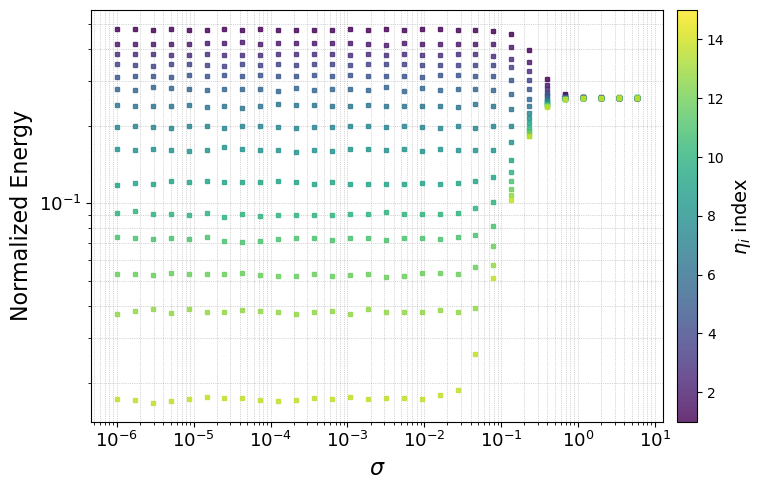

In [22]:
from matplotlib.colors import Normalize
expGenNp= np.array(expGen)
expEmpNp= np.array(expEmp)
plt.figure(figsize=(8, 5)) # Slightly wider for colorbar
n_series = expEmpNp.shape[1]
colors = plt.cm.viridis(np.linspace(0, 0.9, n_series))
data2Plot= expGenNp/np.linalg.norm(expGenNp, axis=1, keepdims= True)
# data2Plot= expEmpNp/np.linalg.norm(expEmpNp, axis=1, keepdims= True)
# 2. Plot Generated Data (Squares)
for i in range(n_series):
    plt.plot(numSpales[:], data2Plot[:, i], 's', markersize=3, alpha=0.8, color=colors[i])


# 4. Create the Colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=Normalize(vmin=1, vmax=n_series))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02, alpha= 0.8)
cbar.set_label(rf"$\eta_{{i}}$ index", fontsize=14)

# Formatting
plt.xlabel(r'$\sigma$', fontsize=16)
plt.ylabel(r'Normalized Energy', fontsize=16)
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.yscale("log")
plt.xscale("log")
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

plt.tight_layout()
plt.show()

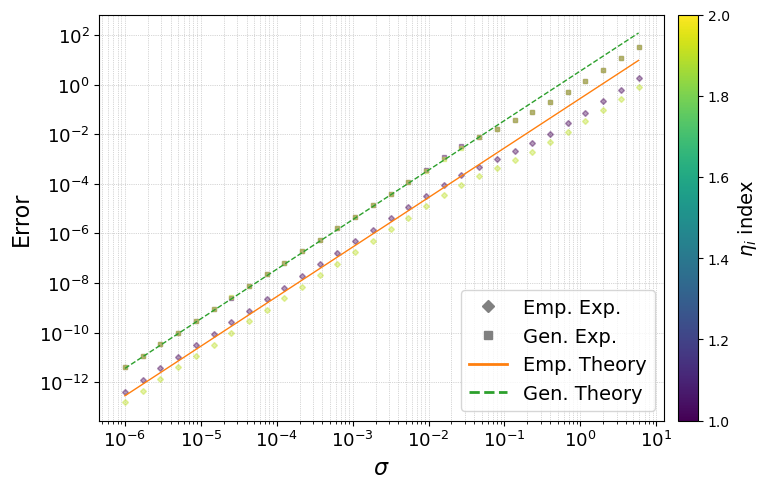

In [112]:
from matplotlib.colors import Normalize
expGenNp= np.array(expGen)
expEmpNp= np.array(expEmp)
plt.figure(figsize=(8, 5)) # Slightly wider for colorbar
n_series = expEmpNp.shape[1]
colors = plt.cm.viridis(np.linspace(0, 0.9, n_series))

# # 1. Plot Empirical Data (Diamonds)
for i in range(n_series):
    plt.plot(numSpales, expEmpNp[:, i], 'D', markersize=3, alpha=0.4, color=colors[i])

# 2. Plot Generated Data (Squares)
for i in range(n_series):
    plt.plot(numSpales, expGenNp[:, i], 's', markersize=3, alpha=0.4, color=colors[i])

# 3. Theory Lines with unique labels and zorder
plt.plot(numSpales, expEmpCal, linewidth=1, label="Emp. Theory", 
         color='C1', linestyle='-', zorder=10)
plt.plot(numSpales, expGenCal, linewidth=1, label="Gen. Theory", 
         color='C2', linestyle='--', zorder=11)

# 4. Create the Colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=Normalize(vmin=1, vmax=n_series))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02, alpha= 1)
cbar.set_label(rf"$\eta_{{i}}$ index", fontsize=14)

# Formatting
plt.xlabel(r'$\sigma$', fontsize=16)
plt.ylabel(r'Error', fontsize=16)
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.yscale("log")
plt.xscale("log")
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
# Now the legend only shows the 2 theory lines and markers
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], marker='D', color='gray', lw=0, label='Empirical'),
                Line2D([0], [0], marker='s', color='gray', lw=0, label='Generated'),
                Line2D([0], [0], color='C1', lw=2, linestyle='-'),
                Line2D([0], [0], color='C2', lw=2, linestyle='--')]

plt.legend(custom_lines, ['Emp. Exp.', 'Gen. Exp.', 'Emp. Theory', 'Gen. Theory'], 
           loc='lower right', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
n= 10
H= np.random.randn(20, n)
U, S, V= np.linalg.svd(H@H.T)
nullH= V[-10:, :].T

rankH= np.linalg.matrix_rank(H)
numPop= 1e3
loops= 10

expEmp= []
expGen= []
expEmpStd= []
expGenStd= []
expEmpCal= []
expGenCal= []
numSpales= []
tmpWants = []
tmpWants2 = []
tmpWantsCal= []
for j in tqdm.tqdm(range(loops)):
    stdOfNoise= 10**(-3+j/loops*3)
    empList= []
    genList= []
    numTrain= 20
    numSpales.append(stdOfNoise)
    tmpWanted= []
    tmpWanted2= []
    for i in range(1000):
        Xipop= np.random.randn(H.shape[1], int(numPop))
        popE= np.random.randn(int(numPop), H.shape[0])
        popZ= (nullH@Xipop).T
        popET= popE*stdOfNoise
        popZE= popZ+popET
        HE= (np.random.randn(numTrain, H.shape[0])*stdOfNoise).T
        HX= np.random.randn(H.shape[1], numTrain)
        HZ= H@HX
        HZE= HZ+HE
        U, S, V= np.linalg.svd(HZE@HZE.T)
        S[:-10]= 0
        NNT= U@np.diag(S)@V
        U, S, V= np.linalg.svd(NNT)
        # NiE= (np.mean(V[-10:, :], axis=0)/np.linalg.norm(np.mean(V[-10  :, :], axis=0)))[:, None]
        NiE= V[-10:, :]
        empList.append(np.mean(np.square(HZE.T@NiE.T), axis= 0))
        genList.append(np.mean(np.square(popZE@NiE.T), axis= 0))

    expEmp.append(np.mean(empList, axis= 0))
    expGen.append(np.mean(genList, axis= 0))
    expEmpStd.append(np.std(empList, axis= 0))
    expGenStd.append(np.std(genList, axis= 0))
    expEmpCal.append(stdOfNoise**2-rankH/numTrain*stdOfNoise**2)
    expGenCal.append(stdOfNoise**2+rankH/(numTrain-n)*stdOfNoise**2)


100%|██████████| 10/10 [00:08<00:00,  1.16it/s]


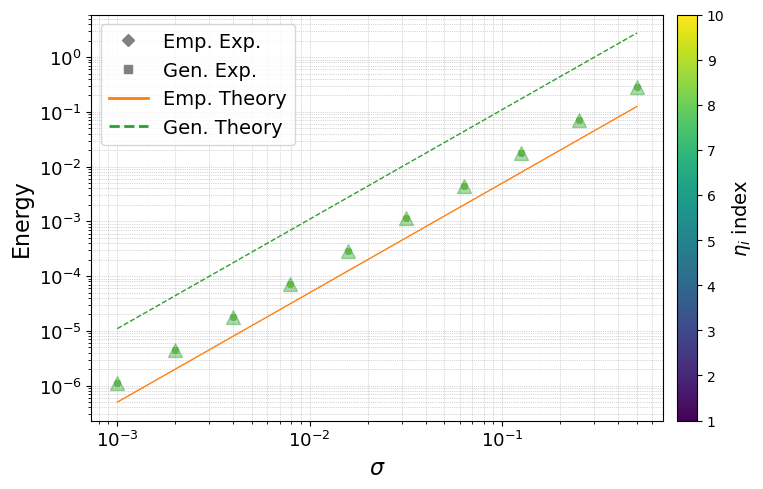

In [62]:
from matplotlib.colors import Normalize
expGenNp= np.array(expGen)
expEmpNp= np.array(expEmp)
plt.figure(figsize=(8, 5)) # Slightly wider for colorbar
n_series = expEmpNp.shape[1]
colors = plt.cm.viridis(np.linspace(0, 0.9, n_series))

# 1. Plot Empirical Data (Diamonds)
# for i in range(n_series):
#     plt.plot(numSpales, expEmpNp[:, i], 'D', markersize=3, alpha=0.4, color=colors[i])

# 2. Plot Generated Data (Squares)
for i in range(n_series):
    plt.plot(numSpales, expGenNp[:, i], 's', markersize=3, alpha=0.4, color=colors[i])

plt.plot(numSpales, np.mean(expGenNp, axis= 1), '^', markersize=10, alpha=0.4, color= "C2")
# 3. Theory Lines with unique labels and zorder
plt.plot(numSpales, expEmpCal, linewidth=1, label="Emp. Theory", 
         color='C1', linestyle='-', zorder=10)
plt.plot(numSpales, expGenCal, linewidth=1, label="Gen. Theory", 
         color='C2', linestyle='--', zorder=11)

# 4. Create the Colorbar
sm = plt.cm.ScalarMappable(cmap=plt.cm.viridis, norm=Normalize(vmin=1, vmax=n_series))
sm.set_array([])
cbar = plt.colorbar(sm, ax=plt.gca(), pad=0.02, alpha= 1)
cbar.set_label(rf"$\eta_{{i}}$ index", fontsize=14)

# Formatting
plt.xlabel(r'$\sigma$', fontsize=16)
plt.ylabel(r'Energy', fontsize=16)
plt.grid(True, which='both', linestyle=':', linewidth=0.5)
plt.yscale("log")
plt.xscale("log")
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
# Now the legend only shows the 2 theory lines and markers
from matplotlib.lines import Line2D
custom_lines = [Line2D([0], [0], marker='D', color='gray', lw=0, label='Empirical'),
                Line2D([0], [0], marker='s', color='gray', lw=0, label='Generated'),
                Line2D([0], [0], color='C1', lw=2, linestyle='-'),
                Line2D([0], [0], color='C2', lw=2, linestyle='--')]

plt.legend(custom_lines, ['Emp. Exp.', 'Gen. Exp.', 'Emp. Theory', 'Gen. Theory'], 
           loc='upper left', fontsize=14)

plt.tight_layout()
plt.show()

In [140]:
AVG= 0
tau= 100000
for i in range(tau):
    X= np.random.randn(2, 4)
    XXT= X@X.T 
    AVG+= np.linalg.inv(XXT)
print(AVG/tau)

[[0.99699524 0.00164611]
 [0.00164611 1.01893389]]


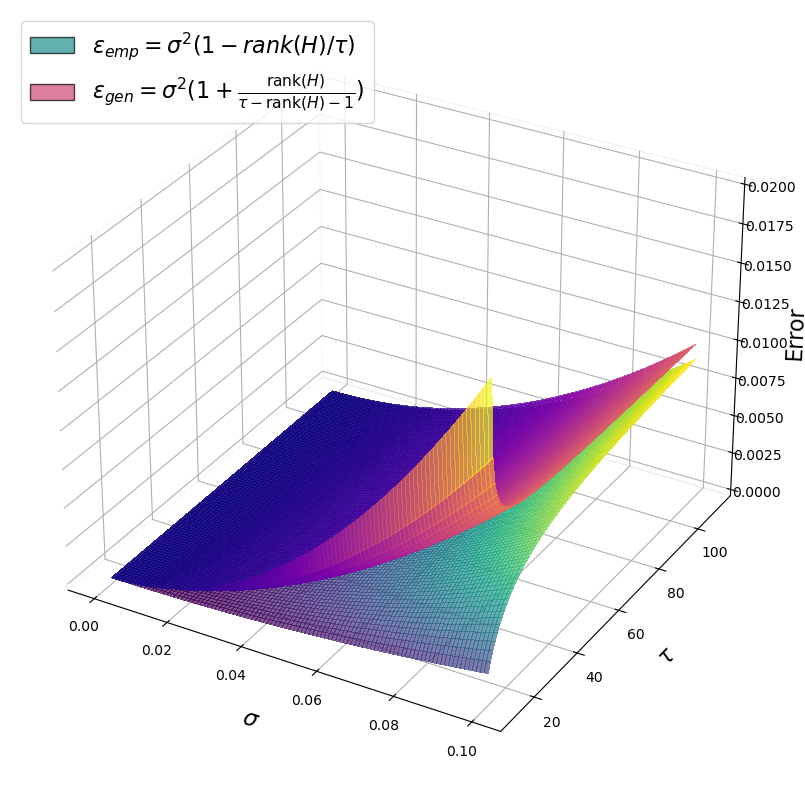

In [23]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# 1. Setup Data
# Let's define rankH since it was missing in your snippet
rankH = 10
m= 20

# Use linear space for clarity, or log if the physics requires it. 
# Your previous def: np.logspace(1e-4, 0.01, 100)-1 was mathematically odd.
# Let's assume you want a small range for 'a':
a_vals = np.linspace(1e-5, 1e-1, 100)
rankH = 10
n_vals = np.linspace(rankH+2, rankH+100, 100)

A, N = np.meshgrid(a_vals, n_vals)

# 2. Calculate Functions
# Naming variables clearly helps debugging
# Using rankH in the label requires us to be consistent
Z1 = A**2 - (A**2 * rankH / N)
Z2 = A**2 + (A**2 / (N - rankH - 1))

# 3. Plotting
fig = plt.figure(figsize=(10, 8)) # Standard landscape aspect ratio
ax = fig.add_subplot(111, projection='3d')

# Plot surfaces with finer strides for smoothness
# 'rcount' and 'ccount' control the downsampling for display speed vs quality
surf1 = ax.plot_surface(A, N, Z1, cmap='viridis', alpha=0.7, 
                        rcount=100, ccount=100, linewidth=0, antialiased=False)
surf2 = ax.plot_surface(A, N, Z2, cmap='plasma', alpha=0.7, 
                        rcount=100, ccount=100, linewidth=0, antialiased=False)

# 4. Refined Labels & Aesthetics
ax.set_xlabel(r'$\sigma$', fontsize=16, labelpad=10)
ax.set_ylabel(r'$\tau$', fontsize=16, labelpad=10)
ax.set_zlabel(r'Error', fontsize=16, labelpad=5)
# ax.set_title(f'Comparison of Surface Functions ($rankH={rankH}$)', fontsize=14)

# Better view angle to see the separation
# ax.view_init(elev=25, azim=-45)

# Clean background for publishing
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False
ax.grid(True, linestyle='--', alpha=0.5)

# 5. Correct Legend
# Using Patches instead of Lines for surfaces
legend_elements = [
    Patch(facecolor=plt.cm.viridis(0.5), edgecolor='k', alpha=0.7,
          label=r'$\varepsilon_{emp}=\sigma^2(1-rank(H)/\tau)$'),
    Patch(facecolor=plt.cm.plasma(0.5), edgecolor='k', alpha=0.7,
          label=r'$\varepsilon_{gen}=\sigma^2(1+\frac{\mathrm{rank}(H)}{\tau-\mathrm{rank}(H)-1})$')
]
ax.legend(handles=legend_elements, loc='upper left', fontsize=16)

plt.tight_layout()

# Save as PDF (Vector graphics) for the paper
plt.savefig('surface_comparison_publish.pdf', dpi=300, bbox_inches='tight')
plt.show()

30
14
57
118


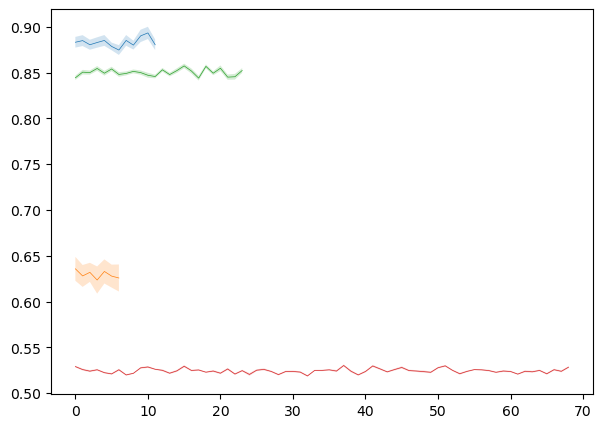

In [217]:
# saveData= dict()
testData= np.log(np.array(experimentRisk2))-np.log(numSpales)[:, None]*2
x= [i for i in range(m-n+1)]
y= np.mean(testData, axis= 0)
yerror= np.var(testData, axis= 0)
saveData[powerID]= [x.copy(), y.copy(), yerror.copy()]
plt.figure(figsize=(7,5))

for id in saveData.keys():
    print(id)
    if id:
        x= saveData[id][0]
        y= saveData[id][1]
        yerror= saveData[id][2]
        plt.plot(x, y, linewidth=0.5)
        plt.fill_between(x, y-yerror*2, y+yerror*2, alpha= 0.2)
# plt.yscale("log")


In [222]:
print(np.log((n-1)/(m-n-1)))
print(np.log((118-1)/(186-118-1)))

0.9555114450274363
0.55748131540679


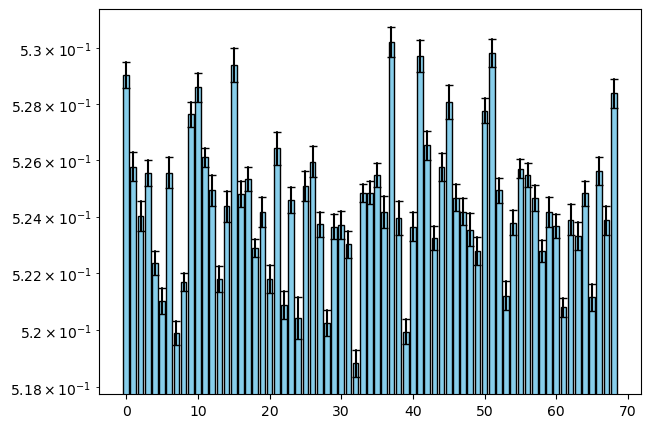

In [225]:
plt.figure(figsize=(7,5))
idd= 118
x= saveData[idd][0]
y= saveData[idd][1]
yerror= saveData[idd][2]
plt.bar(x, y, yerr= yerror, capsize=3, color='skyblue', edgecolor='black')
plt.yscale("log")

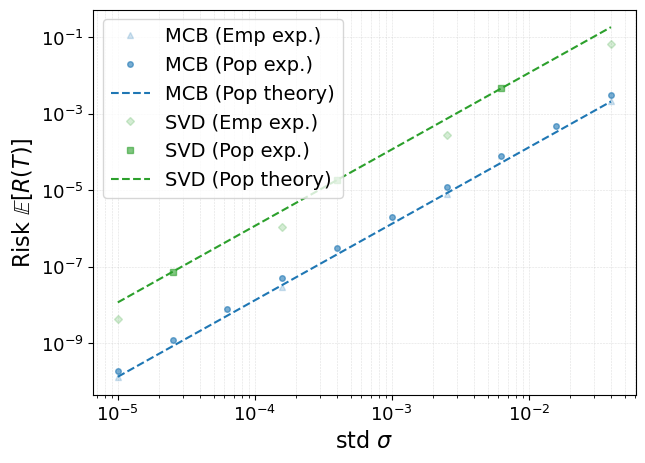

In [358]:
plt.figure(figsize=(7,5))
plt.plot(numSpales[::3], empiricalRiskCyc[::3], '^', markersize=4, alpha=0.2, color='C0', label= "MCB (Emp exp.)")
plt.plot(numSpales[::], experimentRiskCyc[::], 'o', markersize=4, alpha=0.6, color='C0', label= "MCB (Pop exp.)")
plt.plot(numSpales, theorioticalRiskCyc,linewidth=1.5, label= "MCB (Pop theory)", color='C0', linestyle='--')
plt.plot(numSpales[::3], empiricalRisk[::3], 'D', markersize=4, alpha=0.2, color='C2', label= "SVD (Emp exp.)")
plt.plot(numSpales[1::3], experimentRisk[1::3], 's', markersize=4, alpha=0.6, color='C2', label= "SVD (Pop exp.)")
plt.plot(numSpales, theorioticalRisk, linewidth=1.5, label= "SVD (Pop theory)", color='C2', linestyle='--')
plt.xlabel(r'std $\sigma$', fontsize=16)
plt.ylabel(r'Risk $\mathbb{E}[R(T)]$', fontsize=16)
plt.grid(which='both', linestyle='--', linewidth=0.4, alpha=0.4)
plt.yscale("log")
plt.xscale("log")
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)
plt.legend(fontsize=14)

(np.float64(-0.5), np.float64(599.5), np.float64(19.5), np.float64(-0.5))

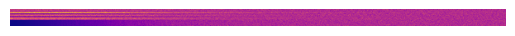

In [52]:
U, S, V= np.linalg.svd(pfData[:numTrain, :])
T= 600
numOFdata= 100
# plt.figure(figsize=(6, 1.5))
noiseMap= np.zeros((T, m))
for i in range(T):
    currentData= H@np.random.randn(H.shape[1], numOFdata)
    noiseVector= np.random.randn(currentData.shape[0], currentData.shape[1])
    noisedData= currentData+noiseVector*i**1.6*0.004
    energy= np.sum(np.abs(V@noisedData), axis= 1)
    noiseMap[i, :]= energy/np.linalg.norm(energy)
plt.imshow(noiseMap.T, cmap=  "plasma")
plt.axis("off")

Text(0.5, 0, 'Measurement')

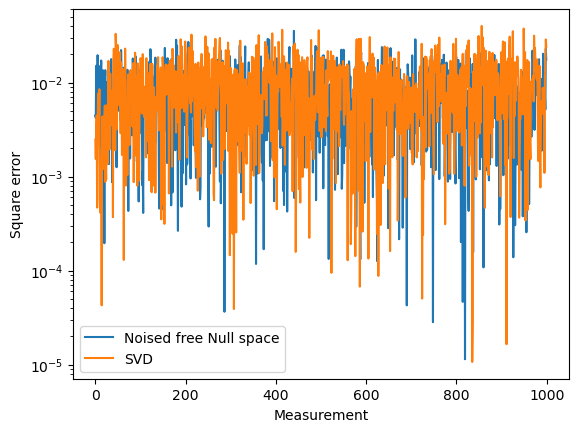

In [318]:
plt.plot(np.linalg.norm(error4[:, 0:1], axis= 1), label= "Noised free Null space")
# print(error4.shape)
plt.plot(np.linalg.norm(error0[:], axis = 1), label="SVD")
plt.yscale("log")
plt.ylabel("Square error")
plt.legend()
plt.xlabel("Measurement")

In [361]:
cSpaceNoise6= compute_detection_subspace(noisePfData[:numTrain, :], n, stdOfNoise)
error6= noisePfData[:numTest, :]@cSpaceNoise6
print(cSpaceNoise6.shape)
print(cSpaceNoise5.shape)

Running Subspace Estimation: K=40 samples, m=20 sensors, n=14 states.
(20, 13)
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Successfully computed detection space basis (shape (20, 7)).
(20, 7)
(20, 7)


[8, 6, 6, 5, 4, 5, 4]
[11, 10, 11, 11, 7, 11, 8]
0.43093820216675816
0.9906174806818923
0.000785761183312633
0.8916875197222455
0.8294792439783063
1.2704392458008515


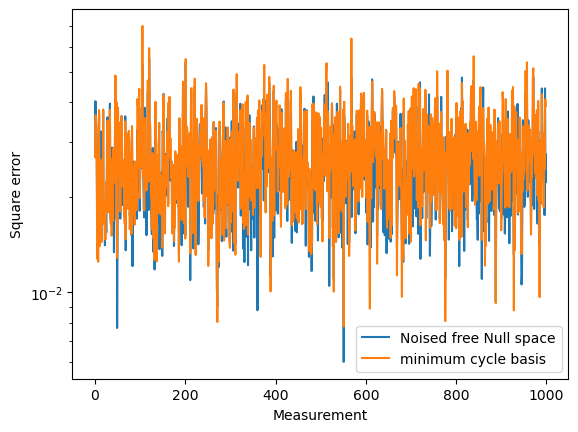

In [69]:
_, cSpaceNoise2, _= resd.cycle_residual(noisePfData[:numTrain, :], rankH, m, noisePfData[numTrain:, :], cycleList2)
error2= (noisePfData[:numTest, :]@cSpaceNoise2)
# print(np.linalg.norm(error0, axis= 0))
# print(np.linalg.norm(error1, axis= 0))
print([n-len(i) for i in cycleList2])
print([n-len(i) for i in cycleList])
print(np.linalg.norm(error0))#svd
print(np.linalg.norm(error2))#largest cycle basis
print(np.linalg.norm(error1)**2/numTest)#simple cycle basis
print(np.linalg.norm(error5))#smallest cycle basis
print(np.linalg.norm(error4))#H mat
print(np.linalg.norm(error6))#H mat

# plt.plot(np.linalg.norm(error2, axis= 1), label= "e2")
plt.plot(np.linalg.norm(error4[:], axis= 1), label= "Noised free Null space")
plt.plot(np.linalg.norm(error5[:], axis= 1), label= "minimum cycle basis")
# plt.plot(np.linalg.norm(error1[:], axis= 1), label= "Trivial cycle basis")
# plt.plot(np.linalg.norm(error6, axis= 1), label= "e6")
# plt.plot(np.linalg.norm(error0, axis= 1), label= "e0")
plt.ylabel("Square error")
plt.xlabel("Measurement")
plt.yscale("log")
plt.legend()

In [34]:
stdOfNoises= []
trueDeltass= []
deltaDivides= []
varSums= []
noiseVector= np.random.randn(pfData.shape[0], pfData.shape[1])
for j in tqdm.tqdm(range(100)):
    stdOfNoise= 2e-2/(j+1)
    stdOfNoises.append(stdOfNoise)
    noiseE= noiseVector*stdOfNoise
    noisePfData= pfData.copy()+noiseE
    trainDataNp= noisePfData[:numTrain, :]
    testDataNp= noisePfData[numTrain:, :]
    errorC, cSpace, _= resd.cycle_residual(trainDataNp, rankH, m, testDataNp, cycleList= cycleList)

    signFun= 1*(cSpace>0)-1*(cSpace<0)
    absSignFun= np.abs(signFun)
    truecSpace= 1/param*signFun
    truecSpace= truecSpace/np.linalg.norm(truecSpace, axis= 0, keepdims= True)
    trueDeltas= 0
    deltaDelta= 0
    varSum= 0
    for i in range(cSpace.shape[1]):
        Zi= (pfData[:numTrain, :]*absSignFun[:, i])
        Ei= (noiseE[:numTrain, :]*absSignFun[:, i])
        Ni= truecSpace[:, i][:, None]
        Deltai= -np.linalg.pinv(Zi)@Ei@Ni
        varI= np.linalg.pinv(Zi.T@Zi)*np.square(stdOfNoise)*np.square(np.linalg.norm(Deltai))
        inferDelta= Deltai[:, 0]
        trueDelta= cSpace[:, i]-truecSpace[:, i]
        varSum+= np.sum(np.diag(varI))
        deltaDelta+= np.sum(np.square(inferDelta-trueDelta))
        trueDeltas+= np.sum(np.square(trueDelta))
        # break
    # deltaDivide= np.sqrt(deltaDelta/trueDeltas)
    trueDeltass.append(trueDeltas)
    deltaDivides.append(deltaDelta)
    varSums.append(varSum)
    # break

100%|██████████| 100/100 [00:00<00:00, 554.51it/s]


In [111]:
trueDeltasss.append(trueDeltass)
deltaDividess.append(deltaDivides)

In [95]:
trueDeltasss= []
deltaDividess= []

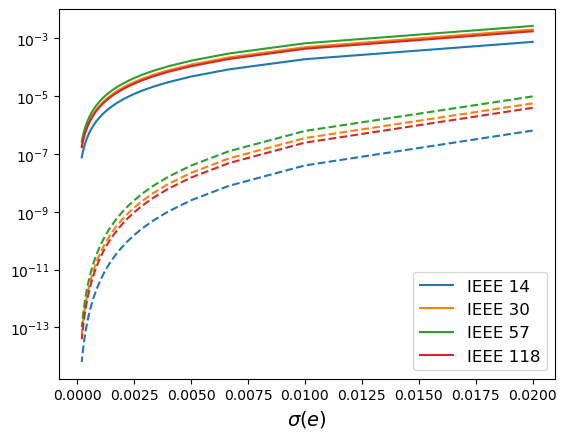

In [134]:
# plt.figure(figsize=(5, 3))
from matplotlib.lines import Line2D

fontSize= 14
tmpColorMap= plt.get_cmap('tab10')
fig, ax = plt.subplots()
for i in range(len(trueDeltasss)):
    ax.plot(stdOfNoises, trueDeltasss[i], color=tmpColorMap(i), label=f"{IEEENames[i]:}")#+r"$\sum\|\bar{\Delta}\|^2$")
    ax.plot(stdOfNoises, deltaDividess[i],linestyle='--', color=tmpColorMap(i), label= f"{IEEENames[i]:}")#+r"$\sum\|\Delta-\bar{\Delta}\|^2$")
# plt.plot(stdOfNoises, np.sqrt(varSums), label=r"$\sqrt{\sum\|Var(\Delta)\|^2}$")
plt.yscale("log")
ax.set_xlabel(r"$\sigma(e)$", fontsize= fontSize)
ax.tick_params(axis='both', labelsize=fontSize-4)
custom_lines = [Line2D([0], [0], color=tmpColorMap(i)) for i in range(len(trueDeltasss))]
plt.legend(custom_lines, IEEENames, fontsize=12)
# plt.legend(fontsize= fontsize-4)

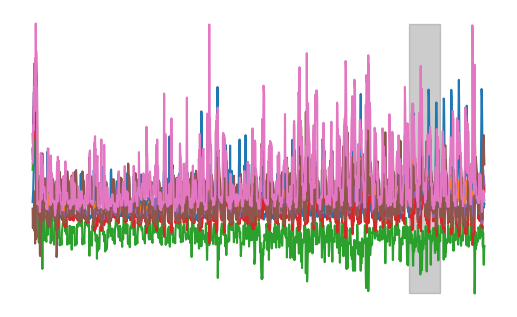

In [15]:
plt.figure(figsize=(5, 3))
plt.plot(testDataNp)
plt.xticks([], [], fontsize= fontsize)
plt.yticks([], [], fontsize= fontsize)
startIdx= np.nonzero(attackPeriod)[0][0]
endIdx= np.nonzero(attackPeriod)[0][-1]
plt.fill_between(range(startIdx, endIdx), np.min(testDataNp), np.max(testDataNp), alpha=0.4, color= "grey")
plt.axis("off")
plt.tight_layout()

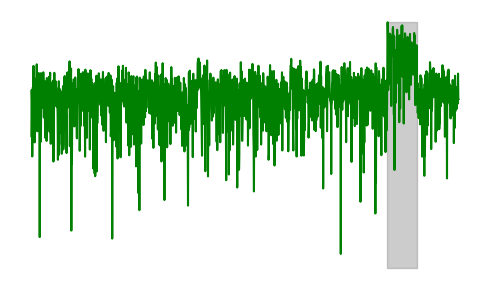

In [5]:
plt.figure(figsize=(5, 3))
# print(errorC.shape)
i= 2
colorMapTmp= ["purple", "orange", "green"]
plt.plot(errorC[i], color= colorMapTmp[i])
plt.yscale("log")
plt.xticks([], [], fontsize= fontsize)
plt.yticks([], [], fontsize= fontsize)
startIdx= np.nonzero(attackPeriod)[0][0]
endIdx= np.nonzero(attackPeriod)[0][-1]
plt.fill_between(range(startIdx, endIdx), np.min(errorC), np.max(errorC), alpha=0.4, color= "grey")
plt.axis("off")
plt.tight_layout()

In [45]:
plt.figure(figsize=(8, 4))
fontsize= 15
legends= [0.002, 0.005, 0.01, 0.02]

plt.rcParams.update({'font.size': fontsize})
for i, residualC in enumerate(residualCs):
    plt.plot(residualC , alpha= 1-i*0.2, label = f"std:{legends[i]}")
    plt.xlabel("Samples", fontsize= fontsize)
    plt.yscale("log")
startIdx= np.nonzero(attackPeriod)[0][0]
endIdx= np.nonzero(attackPeriod)[0][-1]
plt.fill_between(range(startIdx, endIdx), 0, 0.5, alpha=0.2, color= "grey")
plt.ylabel("Reconstruction error", fontsize= fontsize) 
plt.xticks([0, testDataNp.shape[0]], [0, testDataNp.shape[0]])
plt.legend(fontsize= fontsize, loc= 'upper left')

NameError: name 'residualCs' is not defined

<Figure size 800x400 with 0 Axes>

In [92]:
residualCs.append(residualC)

In [76]:
residualCs= []

In [19]:
from sklearn.metrics import precision_recall_curve, auc

mapPrecisionC= np.zeros((m-n+1, 100, 100))
mapPrecisionAll= np.zeros((1, 100, 100))
mapRecallC= np.zeros((m-n+1, 100, 100))
mapRecallAll= np.zeros((1, 100, 100))

originStdMeasurement= np.std((normalPfData-pfData))
LenofOriginAttack= np.sqrt(np.square(originStdMeasurement)*H.shape[0])
ratio= 0.1/LenofOriginAttack/100
ratio2= np.sqrt(0.0245/H.shape[0])
x_axis_label= []
lossCycle= []
lossSVD= []
confidence_level= 0.99
for i in tqdm.tqdm(range(100)):
    scale= (i)*ratio
    newAttackPfData= (normalPfData-pfData)*scale+normalPfData
    stdOfMeasurement= np.std((normalPfData-newAttackPfData))
    lenMeasurement= np.sqrt(np.square(stdOfMeasurement)*H.shape[0])
    x_axis_label.append(str(np.round(lenMeasurement, 3)))
    y_axis_label= []
    for j in range(100):
        noiseStd= ratio2*((j)/100)**3
        lenNoise= np.sqrt(np.square(noiseStd)*H.shape[0])
        y_axis_label.append(str(np.round(lenNoise, 3)))
        tmpMeasurement= (newAttackPfData+noiseVector*noiseStd)
        errorC, cSpace, wholeRight = resd.cycle_residual(tmpMeasurement[:numTrain, :], rankH, m, tmpMeasurement[numTrain:, :], cycleList)
        residualC= np.linalg.norm(errorC, axis= 0)
        if i==0:
            NcSpace= cSpace@np.linalg.inv(cSpace.T@cSpace)@cSpace.T
            lossCycle.append(np.linalg.norm(NcSpace- NcSpaceClean))
        precision, recall, _, _= threshold.li_threshold(residualC, attackPeriod)
        mapPrecisionAll[0, j, i]= precision
        mapRecallAll[0, j, i]= recall
        for k in range(m-n+1):
            precision, recall, _, _= threshold.li_threshold(errorC[k, :], attackPeriod)
            mapPrecisionC[k, j, i]= precision
            mapRecallC[k, j, i]= recall


100%|██████████| 100/100 [00:10<00:00,  9.43it/s]


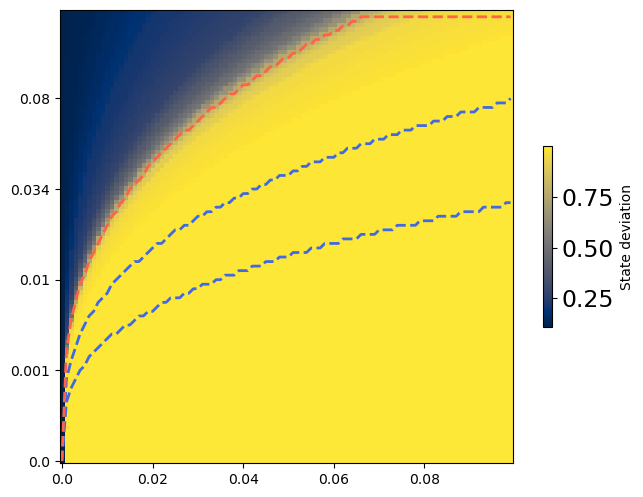

In [20]:
from matplotlib.colors import Normalize
plt.figure()
loadPrevious= False
fontsize= 17 #1 or 15
if loadPrevious:
    powerID= 30
    mapPrecisionC= np.load(f'log/{powerID}_mapPrecisionC.npy')
    mapRecallC= np.load(f'log/{powerID}_mapRecallC.npy')
    mapPrecisionAll= np.load(f'log/{powerID}_mapPrecisionAll.npy')
    mapRecallAll= np.load(f'log/{powerID}_mapRecallAll.npy')
np.save(f'log/{powerID}_mapPrecisionC.npy', mapPrecisionC)
np.save(f'log/{powerID}_mapRecallC.npy', mapRecallC)
np.save(f'log/{powerID}_mapPrecisionAll.npy', mapPrecisionAll)
np.save(f'log/{powerID}_mapRecallAll.npy', mapRecallAll)

f1C= 2*mapPrecisionC*mapRecallC/(mapRecallC+mapPrecisionC+1e-5)
f1All= 2*mapPrecisionAll*mapRecallAll/(mapRecallAll+mapPrecisionAll+1e-5)

heatToShow= f1All[0, :, :]# mapImpact, f1
plotHere= plt.imshow(heatToShow, cmap=  "cividis", norm=Normalize(vmin=np.min(heatToShow), vmax= np.max(heatToShow)), origin='lower')
f1Csum= (f1C[:, ...]>0.8).sum(axis= 1)
f1Allsum= (f1All[0, ...]>0.8).sum(axis= 0)
f1Csum[f1Csum>98.5]= 98
f1Allsum[f1Allsum>98.5]= 98
plt.plot(f1Csum.T, linestyle='dashed',  color= "royalblue", linewidth=2)
plt.plot(f1Allsum, linestyle='dashed', color= "tomato", linewidth=2)
colorbar =plt.colorbar(label= "State deviation", shrink=0.4)
colorbar.ax.tick_params(labelsize= fontsize)
plt.xticks(ticks= [i*20 for i in range(5)], labels= [x_axis_label[i*20] for i in range(5)])
plt.yticks(ticks= [i*20 for i in range(5)], labels= [y_axis_label[i*20] for i in range(5)])
plt.rcParams.update({'font.size': 1})# 15 or 1
# plt.ylabel("Magnitude of the noise vectors", fontsize= fontsize)
# plt.xlabel("Magnitude of the attack vectors", fontsize= fontsize)
plt.tight_layout()
plt.show()

In [9]:
from sklearn.metrics import precision_recall_curve, auc

mapPrcC= np.zeros((m-n+1, 100, 100))
mapPrcAll= np.zeros((1, 100, 100))
mapPrcAllC= np.zeros((1, 100, 100))
mapPrcH= np.zeros((100, 100))
originStdMeasurement= np.std((normalPfData-pfData))
LenofOriginAttack= np.sqrt(np.square(originStdMeasurement)*H.shape[0])
ratio= 0.1/LenofOriginAttack/100
ratio2= np.sqrt(0.0245/H.shape[0])
x_axis_label= []
lossCycle= []
lossSVD= []
confidence_level= 0.99
for i in tqdm.tqdm(range(100)):
    scale= (i)*ratio
    newAttackPfData= (normalPfData-pfData)*scale+normalPfData
    stdOfMeasurement= np.std((normalPfData-newAttackPfData))
    lenMeasurement= np.sqrt(np.square(stdOfMeasurement)*H.shape[0])
    x_axis_label.append(str(np.round(lenMeasurement, 3)))
    y_axis_label= []
    for j in range(100):
        noiseStd= ratio2*((j)/100)**3
        lenNoise= np.sqrt(np.square(noiseStd)*H.shape[0])
        y_axis_label.append(str(np.round(lenNoise, 3)))
        tmpMeasurement= (newAttackPfData+noiseVector*noiseStd)
        errorC, cSpace, wholeRight = resd.cycle_residual(tmpMeasurement[:numTrain, :], rankH, m, tmpMeasurement[numTrain:, :], cycleList)
        residualC= np.linalg.norm(errorC, axis= 0)
        if i==0:
            NcSpace= cSpace@np.linalg.inv(cSpace.T@cSpace)@cSpace.T
            lossCycle.append(np.linalg.norm(NcSpace- NcSpaceClean))
        precision, recall, _ = precision_recall_curve(attackPeriod, residualC)
        pr_auc = auc(recall, precision)
        mapPrcAll[0, j,i]= pr_auc
        for k in range(m-n+1):
            precision, recall, _ = precision_recall_curve(attackPeriod, errorC[k, :])
            pr_auc = auc(recall, precision)
            mapPrcC[k, j,i]= pr_auc
            pass

100%|██████████| 100/100 [00:15<00:00,  6.29it/s]


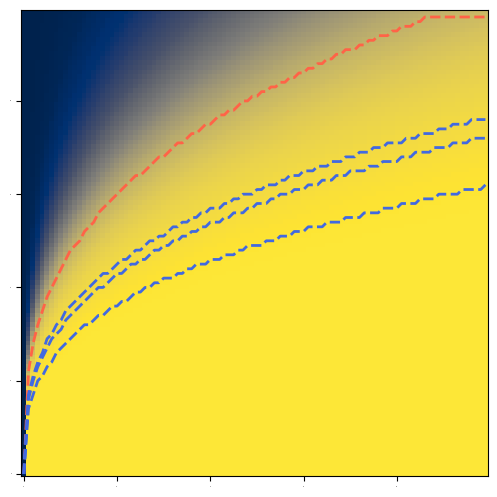

In [10]:
from matplotlib.colors import Normalize
powerID= 14
loadPrevious= 0
fontsize= 17 #1 or 15
plt.figure()

PrcAll= (mapPrcAll[0, ...]>0.8).sum(axis= 0)
PrcAll[PrcAll>98.5]= 98
PrcC= (mapPrcC[:, ...]>0.8).sum(axis= 1)
PrcC[PrcC>98.5]= 98

if loadPrevious:
    mapPrcAll= np.load(f'log/{powerID}_mapPrcAll.npy')
heatToShow= mapPrcAll[0, ...]# 
plotHere= plt.imshow(heatToShow, cmap=  "cividis", norm=Normalize(vmin=np.min(heatToShow), vmax= np.max(heatToShow)), origin='lower')
np.save(f'log/{powerID}_mapPrcAll.npy', mapPrcAll)
if loadPrevious:
    PrcAll= np.load(f'log/{powerID}_PrcAll.npy')
plt.plot(PrcAll, linestyle='dashed',  color= "tomato", linewidth=2)
np.save(f'log/{powerID}_PrcAll.npy', PrcAll)
if loadPrevious:
    PrcC= np.load(f'log/{powerID}_PrcC.npy')
plt.plot(PrcC.T, linestyle='dashed',  color= "royalblue", linewidth=2)
np.save(f'log/{powerID}_PrcC.npy', PrcC)
# colorbar =plt.colorbar(label= "PR-AUC", shrink=0.4)
# colorbar.ax.tick_params(labelsize=fontsize)
# plt.xticks(ticks= [i*20 for i in range(5)], labels= [x_axis_label[i*20] for i in range(5)])
# plt.yticks(ticks= [i*20 for i in range(5)], labels= [y_axis_label[i*20] for i in range(5)])
plt.rcParams.update({'font.size': 1})
# plt.ylabel("Magnitude of the noise vectors", fontsize= fontsize)
# plt.xlabel("Magnitude of the attack vectors", fontsize= fontsize)
plt.tight_layout()
plt.show()

In [ ]:

colors= ["blue", "green", "purple", "pink"]
for i in range(len(lossCycles)):
    plt.plot(lossCycles[i], label= f"Cycle-based {IEEENames[i]}", color= colors[i])
    # plt.plot(lossSVDs[i], "--", label= f"SVD-based {IEEENames[i]}",  color= colors[i])
# plt.yscale("log")
plt.xticks(ticks= [0]+[19+i*20 for i in range(5)], labels= [0]+[y_axis_label[19+i*20] for i in range(5)])
plt.rcParams.update({'font.size': 15})
plt.xlabel("Magnitude of the noise vectors")
plt.ylabel("Projection matrix error")
plt.legend()
plt.tight_layout()

NameError: name 'lossCycles' is not defined

In [202]:
lossCycles.append(lossCycle)
lossSVDs.append(lossSVD)

In [185]:
lossCycles= []
lossSVDs= []

56
746


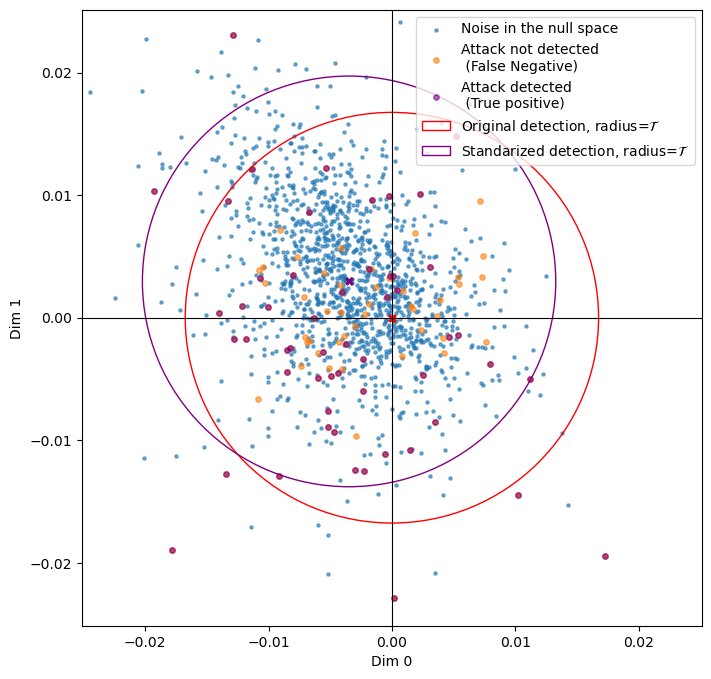

In [217]:
nullH2D= nullH[:, [6, 1]]# 6, 10, 11

tau= threshold_li(residualH)
limRange= tau*1.5
visul2D= nullH2D.T@pfDatanor.T
center2= nullH2D.T@(np.mean(pfDatanor, 0, keepdims= True).T)
center2= (center2[0], center2[1])
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(visul2D[0, attackPeriod==0], visul2D[1, attackPeriod==0], s= 5, alpha=0.6, label= "Noise in the null space")
attackDetc= residualH>tau
cross= np.sum(attackDetc*(attackPeriod>1e-5))
negcross= np.sum((1-attackDetc)*(1-attackPeriod>1e-5))
print(cross)
print(negcross)
ax.scatter(visul2D[0, attackPeriod>1e-5], visul2D[1, attackPeriod>1e-5], s= 15, alpha=0.6, label= "Attack not detected \n (False Negative)")

ax.scatter(visul2D[0, attackDetc*(attackPeriod>1e-5)], visul2D[1, attackDetc*(attackPeriod>1e-5)], s= 15, alpha=0.6,  color='purple', label= "Attack detected \n (True positive)")

circle1= plt.Circle((0, 0), radius= tau, color='red', fill=False, linewidth=1, label= "Original detection, radius=$\mathcal{T}$")
ax.add_patch(circle1)
circle2= plt.Circle(center2, radius= tau, color='purple', fill=False, linewidth=1, label= "Standarized detection, radius=$\mathcal{T}$")
ax.add_patch(circle2)
ax.scatter(0, 0, s= 40, alpha=1, color='red', marker= "X", linewidths= 0.01)
ax.scatter(center2[0], center2[1], s= 40, alpha=1, color='purple', marker= "X", linewidths= 0.01)
plt.xlabel("Dim 0")
plt.ylabel("Dim 1")
plt.axhline(0, color='black', linewidth=0.8)  # x-axis
plt.axvline(0, color='black', linewidth=0.8)  # y-axis
plt.xlim(-limRange, limRange)
plt.ylim(-limRange, limRange)
plt.legend()

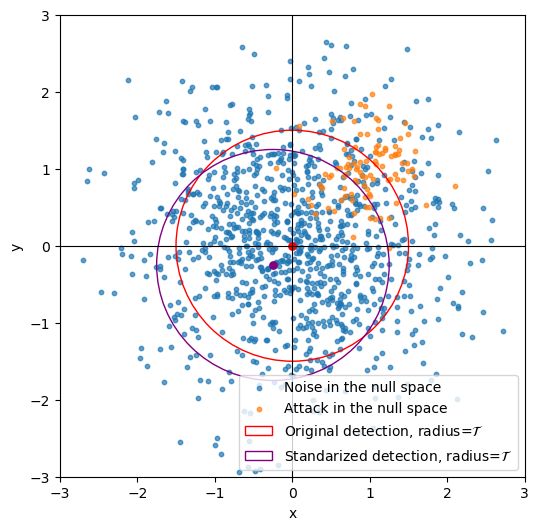

In [178]:
# Set random seed for reproducibility (optional)
np.random.seed(42)
biasXY= (1, 1)

# Sample 100 points from a Gaussian distribution with mean=0, variance=1
x = np.random.normal(loc=0.0, scale=1.0, size=1000)
y = np.random.normal(loc=0.0, scale=1.0, size=1000)

xA = np.random.normal(loc=0.0, scale=0.4, size=100)+biasXY[0]
yA = np.random.normal(loc=0.0, scale=0.4, size=100)+biasXY[1]

# Plotting
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(x, y, s= 10, alpha=0.7, label= "Noise in the null space")
ax.scatter(xA, yA, s= 10, alpha=0.7, label= "Attack in the null space")
ax.scatter(0, 0, s= 40, alpha=1, color='red', marker= "o", linewidths= 0.01)
circle1= plt.Circle((0, 0), radius=1.5, color='red', fill=False, linewidth=1, label= "Original detection, radius=$\mathcal{T}$")
center2= (-biasXY[0]/4, -biasXY[1]/4)
ax.scatter(center2[0], center2[1], s= 40, alpha=1, color='purple', marker= "o", linewidths= 0.01)
circle2= plt.Circle(center2, radius=1.5, color='purple', fill=False, linewidth=1, label= "Standarized detection, radius=$\mathcal{T}$")
ax.add_patch(circle1)
ax.add_patch(circle2)
plt.xlabel("x")
plt.ylabel("y")
plt.axhline(0, color='black', linewidth=0.8)  # x-axis
plt.axvline(0, color='black', linewidth=0.8)  # y-axis

plt.xlim(-3, 3)
plt.ylim(-3, 3)
plt.grid(False)
plt.legend()
plt.show()

num links
20
20
num links


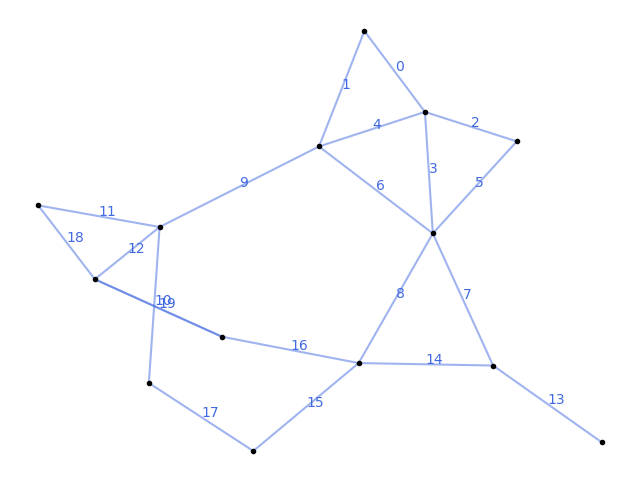

In [75]:
G, node_pair2id= graph.from_A_to_G(A[:, :])
print("num links")
print(G.number_of_edges())
print(m)
print("num links")
G= G.to_undirected()
biconnected_components = list(nx.biconnected_components(G))
largest_bcc = list(max(biconnected_components, key=len))

plotGraph.plot_spring_layout(G, label= False, label_edge= True, node_pair2id= node_pair2id)